# Prediction of the Total and Formation Energies of Metal Nanoparticles: Models Training and Evaluation

This notebook contains the models training and evaluation results from the machine learning predictions of the total and formation energies of monometallic gold, palladium, and platinum nanoparticles, in attempt to explore the possibility of representing the whole training dataset by a set of archetypal samples to save computational costs.

## Outline

[Notebook Setups](#setup)

[Monometallic Nanoparticles](#mnps)

<a id='setup'></a>
## Notebook Setups

In [46]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
# Import relevant libraries
# from os import chdir
from os.path import exists
import pickle

import lightgbm
import scipy
import seaborn as sns
import sklearn

from lightgbm import LGBMRegressor
# from natsort import natsorted
import numpy as np
from scipy import stats
# from sklearnex import patch_sklearn; 
# patch_sklearn()
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# chdir('/scratch/q27/jt5911/metal-nanoparticle-causal-path-probability/strategicInf')
from trainEvalModels import *

# Print package versions for reproducibility
print('Versions of imported libraries:')
print(f"  lightgbm: {lightgbm.__version__}")
print(f"  matplotlib: {mpl.__version__}")
print(f"  numpy: {np.__version__}")
print(f"  pandas: {pd.__version__}")
print(f"  scipy: {scipy.__version__}")
print(f"  scikit-learn: {sklearn.__version__}")
print(f"  seaborn: {sns.__version__}")

Versions of imported libraries:
  lightgbm: 4.6.0
  matplotlib: 3.10.9
  numpy: 2.4.4
  pandas: 3.0.2
  scipy: 1.17.1
  scikit-learn: 1.8.0
  seaborn: 0.13.2


Below are some general settings for plotting figures:

In [48]:
# Settings for figures
sns.set_theme(context='paper', style='ticks', palette='colorblind', font='sans-serif', font_scale=1, color_codes=True, rc=None)  # Options are: {paper, notebook, talk, poster}
figSize, fontSize, labelSize = (3.5, 2.5), 'medium', 'small'
legendSize, lineWidth, markerSize = 'x-small', 1, 3
# SMALL_SIZE, MEDIUM_SIZE, LARGE_SIZE, TITLE_SIZE = 8, 10, 12, 14
# plt.rc('font', size=LARGE_SIZE)  # controls default text sizes
# plt.rc('axes', titlesize=TITLE_SIZE)  # fontsize of the axes title
# plt.rc('axes', labelsize=LARGE_SIZE)  # fontsize of the x and y labels
# plt.rc('xtick', labelsize=LARGE_SIZE)  # fontsize of the tick labels
# plt.rc('ytick', labelsize=LARGE_SIZE)  # fontsize of the tick labels
# plt.rc('legend', fontsize=LARGE_SIZE)  # legend fontsize
# plt.rc('figure', titlesize=TITLE_SIZE)  # fontsize of the figure title

In [ ]:
# Global variables
SCALING = 'minmax'  # {None, 'minmax', 'standard', 'yeo-johnson'}
POLY_FEATS = False
NUM_JOBS = 12
VERBOSE = True
RANDOM_SEED = 42
NUM_RUNS = 10
CORR_THRESH = 0.8

DATA_DIR = '/home/DART/jonathant/Documents/iterative-archetypal-analysis/metal-nanoparticle-energy-regression/data'
FIG_DIR = '/home/DART/jonathant/Documents/iterative-archetypal-analysis/metal-nanoparticle-energy-regression/figs'

label_dict = {
    'Total_E': {'label': 'Etot', 'name': 'Total Energy'},
    'Formation_E': {'label': 'Eform', 'name': 'Formation Energy'}
}

In [50]:
def loadFeats(pklFilePath):
    """
    Load feature dataframe saved in pickle file.
    """
    with open(pklFilePath, 'rb') as f:
        featsDF = pickle.load(f)
    return featsDF

In [51]:
def rmNullFeats(featsDF, verbose=False):
    if verbose:
        print(f"Removing the features with null values...")
        print(f"  Original number of features: {len(featsDF.columns)}")
    featsToDrop = []
    for feat in featsDF.columns:
        if featsDF[feat].isnull().any():
            featsToDrop.append(feat)
    featsNoNullDF = featsDF.drop(featsToDrop, axis=1, inplace=False)
    if verbose:
        print(f"  Total number of features left: {len(featsNoNullDF.columns)}\n")
    return featsNoNullDF

In [52]:
def genModel(hpValDict, modelName):
    if modelName == 'RFR':
        kwargs = {'n_estimators': 100, 'criterion': 'squared_error', 
                  # Adjust to deal with overfitting and speed up training
                  'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 
                  'min_samples_split': 2, 'min_samples_leaf': 1, 'min_impurity_decrease': 0.0, 'ccp_alpha': 0.0, 
                  # Parameters to be fixed
                  'min_weight_fraction_leaf': 0.0, 'bootstrap': True, 'warm_start': False, 
                  'monotonic_cst': None, 'oob_score': False, 'n_jobs': NUM_JOBS, 'random_state': RANDOM_SEED, 'verbose': 0}
    elif modelName == 'LGB':
        kwargs = {'num_leaves': 31, 'min_child_samples': 20, 'learning_rate': 0.1, 'n_estimators': 100, 
                  # Adjust to deal with overfitting
                  'min_child_weight': 0.001, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 
                  'subsample': 1.0, 'subsample_freq': 0, 'colsample_bytree': 1.0, 
                  # Adjust to speed up training
                  'min_split_gain': 0.0, 'subsample_for_bin': 200000, 'max_bin': 255, 'max_depth': -1, 
                  # Parameters to be fixed
                  'boosting_type': 'gbdt', 'importance_type': 'gain', 'tree_learner': 'data', 
                  'objective': 'regression', 'class_weight': None, 'use_missing': True,
                  'random_state': RANDOM_SEED, 'n_jobs': NUM_JOBS, 'force_row_wise': True, 'verbose': -1}

    for hp in hpValDict.keys():
        kwargs[hp] = hpValDict[hp]
        
    if modelName == 'RFR':
        return RandomForestRegressor(**kwargs)
    elif modelName == 'LGB':
        return LGBMRegressor(**kwargs)

In [53]:
def getTrainTestScores(dataset, hpsValsDicts, modelName):
    Xtrain, Xtest, yTrain, yTest = dataset
    trainScores, testScores = [], []
    for hpsValsDict in hpsValsDicts:
        reg = genModel(hpsValsDict, modelName)
        reg.fit(Xtrain, yTrain)
        trainScores.append(reg.score(Xtrain, yTrain))
        testScores.append(reg.score(Xtest, yTest))
    return trainScores, testScores

In [54]:
def hpVSr2(xVals, scores, xlabel, figSize=(7, 2.5)):
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=['#303F9F', '#FF5252', '#D32F2F'])
    if len(scores) == 1:
        trainScores, testScores = scores[0]
        plt.figure(figsize=figSize)
        if all(isinstance(xVal, str) for xVal in xVals):
            plt.bar(xVals, trainScores)
            plt.bar(xVals, testScores)
        else:
            plt.plot(xVals, trainScores)
            plt.plot(xVals, testScores)
            plt.xlabel(xlabel)
        plt.grid(linestyle='dotted')
        plt.ylabel('R2 score')
        plt.legend(['Train', 'Test']);
    else:
        fig, axes = plt.subplots(1, len(scores), figsize=figSize)
        for i, (trainScores, testScores) in enumerate(scores):
            if all(isinstance(xVal, str) for xVal in xVals):
                axes[i].bar(xVals, trainScores)
                axes[i].bar(xVals, testScores)
            else:
                axes[i].plot(xVals, trainScores)
                axes[i].plot(xVals, testScores)
            axes[i].grid(linestyle='dotted')
            axes[i].legend(['Train', 'Test'])
        fig.text(0.5, -0.03, xlabel, ha='center')
        fig.text(0.05, 0.5, 'R2 score', va='center', rotation='vertical');

<a id='mnps'></a>
## Monometallic Nanoparticles

Here we attempt to train machine learning models that aim to predict the total and formation energies of a set of simulated monometallic nanoparticles (either gold, palladium, or platinum), to explore how well do the reduced dataset consisting of the most archetypal samples represent the whole dataset.

### Whole dataset

Removing the features with null values...
  Original number of features: 52
  Total number of features left: 52

Applying minmax scaling to feature values...
Applying minmax scaling to feature values...

Dataset: MNP
  Running LRR
  Trained and tested using Coefficient of determination.
    Training score: 0.981
    Cross-validation score: 0.981 +/- 0.002
    Testing score:
      Mean absolute error: 1417.320093
      Mean squared error: 5480140.704134
      Root mean squared error: 2340.970035
      Coefficient of determination: 0.979


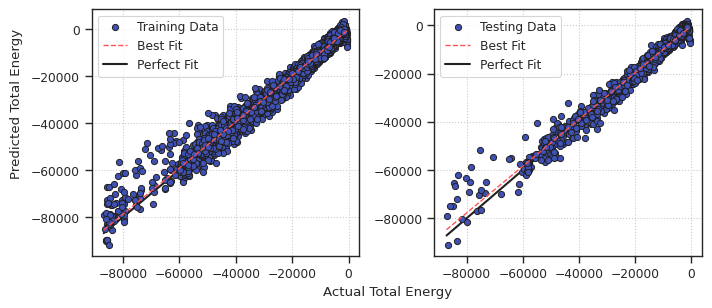

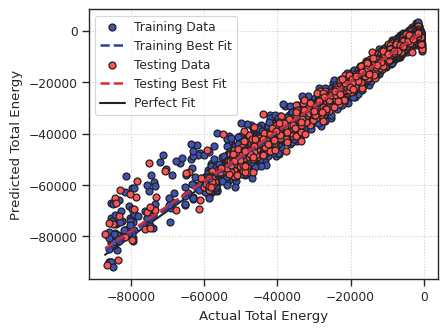

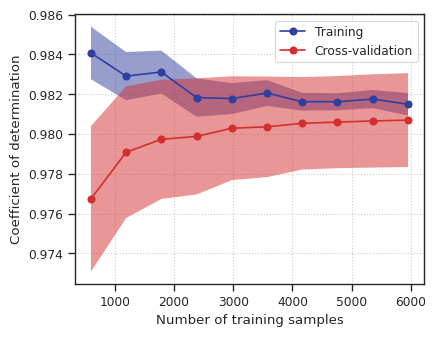

  Feature coefficients:
    time: 1450.869
    MM_SCN_avg: 974.936
    S_110: 9007.368
    R_diff: 13770.748
    MMM_BA1_avg: 3691.362
    DECA: 2940.781
    Curve_11-20: 3545.164
    Curve_61-70: 1179.682
    MM_SCN_1: 847.133
    MM_SCN_8: 9104.713
    MM_SCN_14: 151.012
    q6q6_S_3: 6597.612
    q6q6_S_12: 7668.449
    MM_TCN_15: 4029.577
    MM_TCN_17: 523.206
    q6q6_T_13: 190.847
    q6q6_T_15: 80.745
    MM_BCN_5: 1547.542
    MM_BCN_8: 5439.007
    q6q6_B_4: 4892.932

Dataset: MNP
Best score: 0.987
Best parameter combination: {'criterion': 'friedman_mse', 'max_depth': 8, 'max_features': np.float64(0.4003377500251196), 'max_leaf_nodes': 28, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 90}
  Running RFR
  Trained and tested using Coefficient of determination.
    Training score: 0.990
    Cross-validation score: 0.987 +/- 0.002
    Testing score:
      Mean absolute error: 1057.060362
      Mean squared error: 3605167.441010
      Root mean squared error: 1898

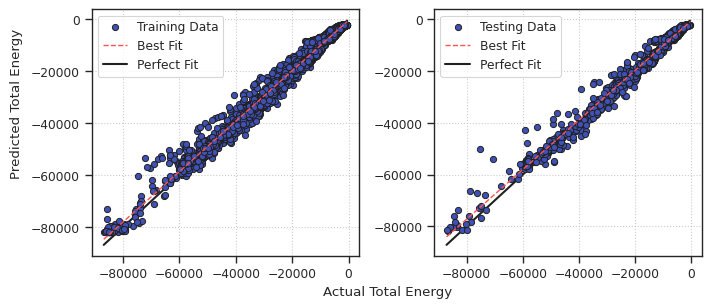

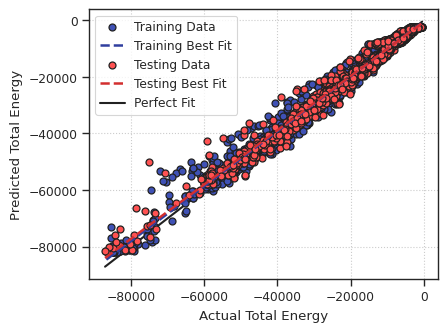

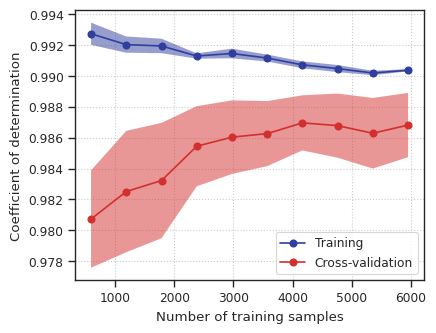

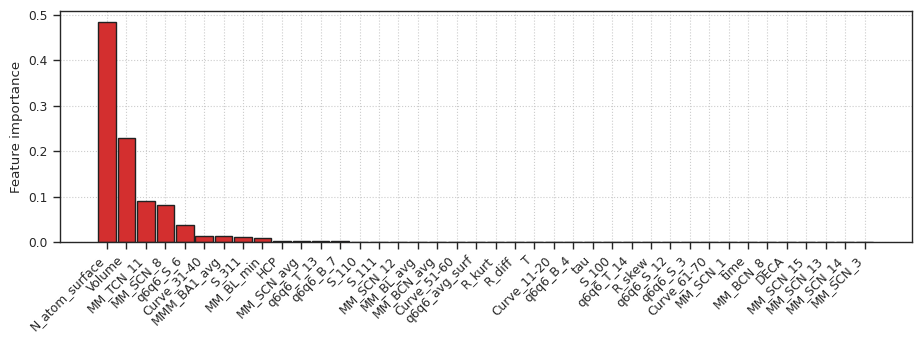

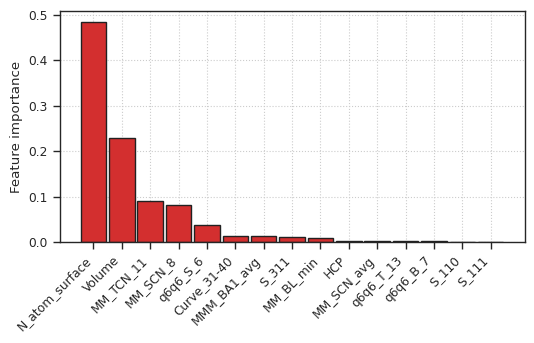

Removing the features with null values...
  Original number of features: 52
  Total number of features left: 52

Applying minmax scaling to feature values...
Applying minmax scaling to feature values...

Dataset: MNP
  Running LRR
  Trained and tested using Coefficient of determination.
    Training score: 0.957
    Cross-validation score: 0.956 +/- 0.003
    Testing score:
      Mean absolute error: 130.012205
      Mean squared error: 35735.367470
      Root mean squared error: 189.038005
      Coefficient of determination: 0.959


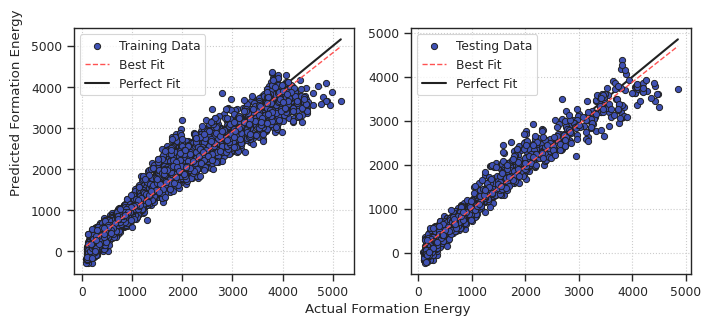

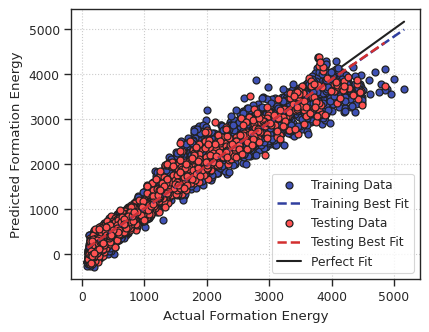

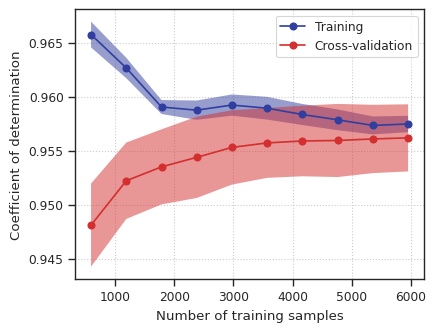

  Feature coefficients:
    T: 512.375
    S_100: 375.041
    S_111: 790.743
    S_311: 747.748
    N_atom_surface: 3170.216
    R_skew: 267.880
    R_kurt: 284.498
    MM_BCN_avg: 340.712
    MM_BL_min: 338.119
    DECA: 363.548
    Curve_31-40: 1030.471
    Curve_51-60: 420.923
    Curve_61-70: 106.880
    Curve_71-80: 70.814
    MM_SCN_1: 10.476
    MM_SCN_2: 10.840
    MM_SCN_8: 947.274
    MM_SCN_15: 135.267
    q6q6_S_6: 455.507
    q6q6_S_13: 114.758
    MM_TCN_11: 2252.309
    MM_TCN_16: 14.155
    MM_TCN_17: 163.837
    q6q6_T_13: 1458.221
    q6q6_T_15: 139.367
    MM_BCN_5: 2.732
    MM_BCN_6: 35.182
    q6q6_B_7: 64.545

Dataset: MNP
Best score: 0.966
Best parameter combination: {'criterion': 'friedman_mse', 'max_depth': 8, 'max_features': np.float64(0.4003377500251196), 'max_leaf_nodes': 28, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 90}
  Running RFR
  Trained and tested using Coefficient of determination.
    Training score: 0.971
    Cross-validation

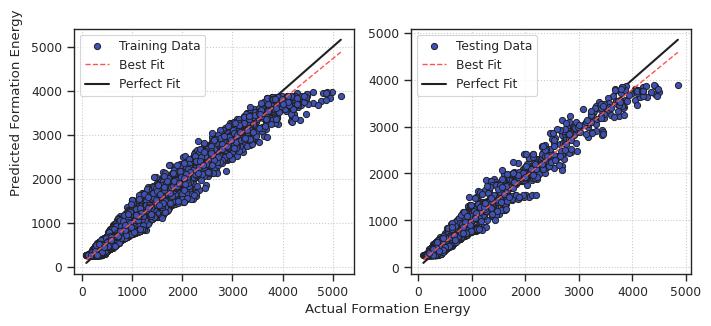

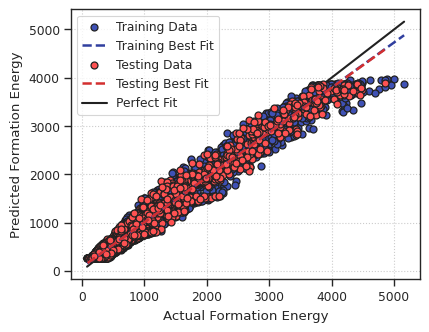

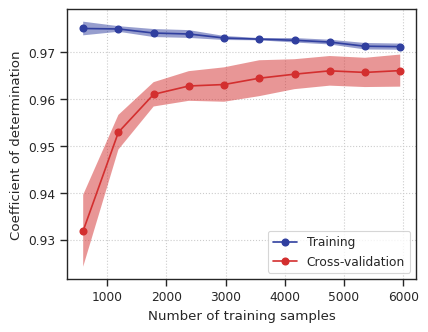

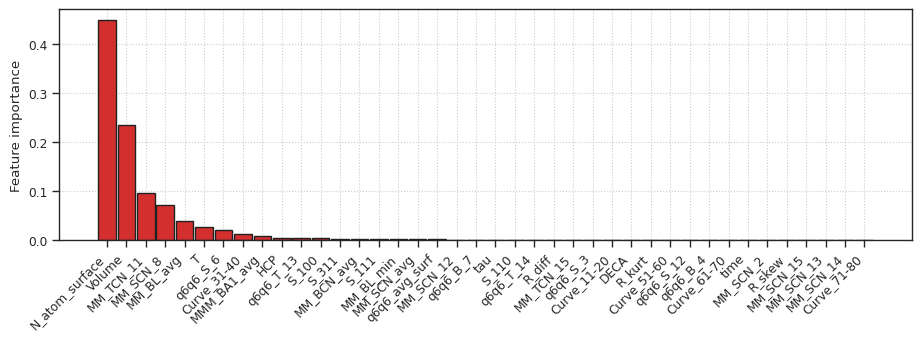

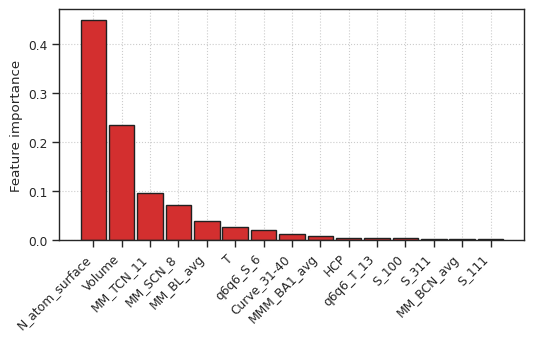

In [ ]:
for label in ('Total_E', 'Formation_E'):
    FIG_NAME_APPENDIX = f"{label_dict[label]['label']}_minmax"

    # Data loading
    MNPDF = pd.read_pickle(f"{DATA_DIR}/processed/processedMNPEdataNoC{int(CORR_THRESH * 100)}.pkl")
    other_label = 'Formation_E' if label == 'Total_E' else 'Total_E'
    MNPDF = MNPDF.drop([other_label], axis=1)
    
    MNPNoNullDF = rmNullFeats(featsDF=MNPDF, verbose=VERBOSE)
    
    XtrainMNP, XtestMNP, yTrainMNP, yTestMNP = splitScaleData(df=MNPDF, polyFeats=POLY_FEATS, scaling=SCALING, verbose=VERBOSE)
    XtrainMNPNoNull, XtestMNPNoNull, yTrainMNPNoNull, yTestMNPNoNull = splitScaleData(df=MNPNoNullDF, polyFeats=POLY_FEATS, scaling=SCALING, verbose=VERBOSE)
    
    X_Y_MNPS = {'WithNull': {'MNP': (XtrainMNP, XtestMNP, yTrainMNP, yTestMNP)}, 
                'NoNull': {'MNP': (XtrainMNPNoNull, XtestMNPNoNull, yTrainMNPNoNull, yTestMNPNoNull)}}

    # Linear Regression
    hasMissingVals, modelName = 'NoNull', 'LRR'
    for mnp in X_Y_MNPS[hasMissingVals].keys():
        print(f"\nDataset: {mnp}")
        Xtrain, Xtest, yTrain, yTest = X_Y_MNPS[hasMissingVals][mnp]
        
        linReg = LinearRegression(positive=False, fit_intercept=True, 
                                  copy_X=True, n_jobs=NUM_JOBS)  # No speedup from n_jobs here as n_target=1 and positive=False
        cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
        yPredTrainLinR, yPredTestLinR, linReg = runModel(Xtrain, yTrain, Xtest, yTest, cv,
                                                         model=linReg, modelName=modelName, datasetName=mnp, figNameAppendix=FIG_NAME_APPENDIX,
                                                         numFeat=20, isReg=True, label=label_dict[label]['name'], showFeatCoef=True, plotFeatImp=False, verbose=True, showFig=True)

    # Random Forest
    hasMissingVals, modelName = 'WithNull', 'RFR'
    for mnp in X_Y_MNPS[hasMissingVals].keys():
        print(f"\nDataset: {mnp}")
        if exists(f"{DATA_DIR}/hpTune/hpTune{mnp}{modelName}_{FIG_NAME_APPENDIX}.pkl"):
            print('Already done, skipping...')
            continue
        Xtrain, Xtest, yTrain, yTest = X_Y_MNPS[hasMissingVals][mnp]
    
        rfReg = RandomForestRegressor(n_estimators=5, criterion='squared_error', max_depth=None, 
                                      max_features=1.0, max_leaf_nodes=None, min_samples_split=2, min_samples_leaf=1, 
                                      min_impurity_decrease=0.0, min_weight_fraction_leaf=0.0, n_jobs=NUM_JOBS, random_state=RANDOM_SEED, verbose=0, 
                                      bootstrap=True, oob_score=False, warm_start=False, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)
        paramGrid = {'criterion': ['squared_error', 'absolute_error', 'friedman_mse'], 
                     'n_estimators': stats.randint(low=3, high=100), 
                     'max_depth' : stats.randint(low=1, high=10), 
                     'max_features': stats.uniform(loc=0.1, scale=0.9), 
                     'max_leaf_nodes': stats.randint(low=5, high=100),
                     'min_samples_split': stats.randint(low=2, high=20), 
                     'min_samples_leaf': stats.randint(low=1, high=10)}
        cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
        searchResults = hyperparamTune(rfReg, paramGrid, Xtrain, yTrain, scoringMetric='r2', cv=cv, numIter=2)
        with open(f"{DATA_DIR}/hpTune/hpTune{mnp}{modelName}_{FIG_NAME_APPENDIX}.pkl", 'wb') as f:
            pickle.dump(searchResults, f)
    
        rfReg = searchResults.best_estimator_
        yPredTrainRFR, yPredTestRFR, rfReg = runModel(Xtrain, yTrain, Xtest, yTest, cv,
                                                      model=rfReg, modelName=modelName, datasetName=mnp, figNameAppendix=FIG_NAME_APPENDIX,
                                                      numFeat=15, label=label_dict[label]['name'], showFeatCoef=False, plotFeatImp=True, verbose=True, showFig=True)
        # Note: Set 'showFig' to False for cluster jobs!

### Reduced dataset with archetypes

Removing the features with null values...
  Original number of features: 56
  Total number of features left: 56

Applying minmax scaling to feature values...
Applying minmax scaling to feature values...

Dataset: MNP
  Running LRR
  Trained and tested using Coefficient of determination.
    Training score: 0.995
    Cross-validation score: 0.981 +/- 0.004
    Testing score:
      Mean absolute error: 2106.750775
      Mean squared error: 9679831.004416
      Root mean squared error: 3111.242678
      Coefficient of determination: 0.972


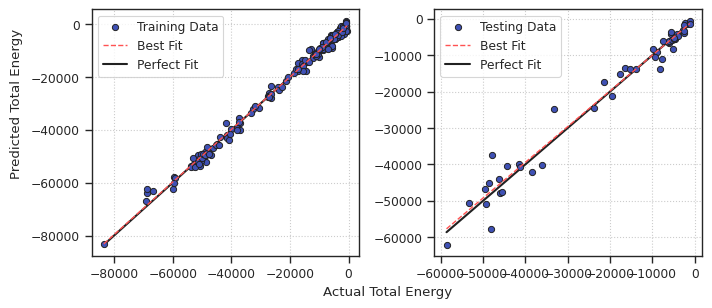

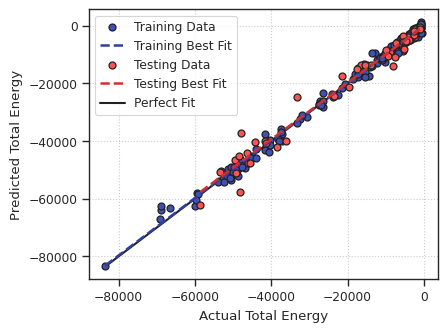

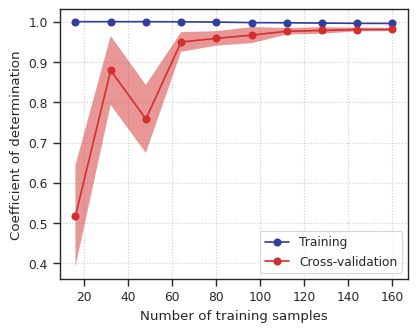

  Feature coefficients:
    time: 702.635
    Volume: 3558.193
    R_diff: 1056.930
    R_kurt: 3042.232
    Curve_11-20: 10712.913
    Curve_31-40: 40710.445
    Curve_61-70: 1835.805
    MM_TCN_7: 13267.825
    MM_TCN_8: 2850.790
    MM_TCN_14: 314.541
    MM_TCN_15: 2545.771
    MM_TCN_16: 1112.024
    MM_BCN_5: 150.808
    MM_BCN_8: 5373.823
    MM_SCN_14: 392.317
    MM_BL_std: 17878.628
    MMM_BA1_avg: 4753.293
    DECA: 6161.130
    q6q6_avg_total: 5315.784
    q6q6_S_12: 13183.177

Dataset: MNP
Best score: 0.962
Best parameter combination: {'criterion': 'friedman_mse', 'max_depth': 8, 'max_features': np.float64(0.4003377500251196), 'max_leaf_nodes': 28, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 90}
  Running RFR
  Trained and tested using Coefficient of determination.
    Training score: 0.989
    Cross-validation score: 0.962 +/- 0.010
    Testing score:
      Mean absolute error: 1584.358337
      Mean squared error: 7772907.158755
      Root mean square

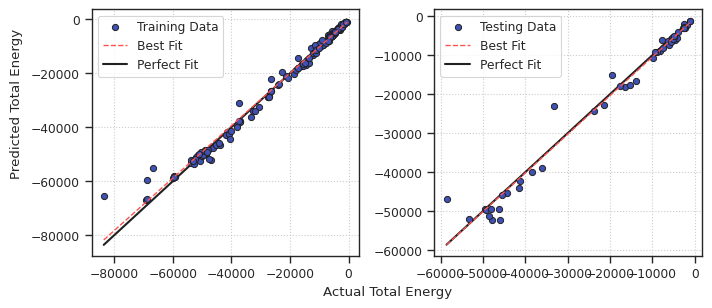

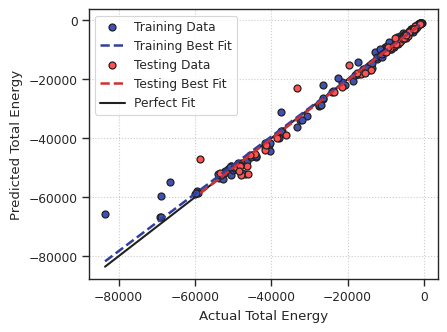

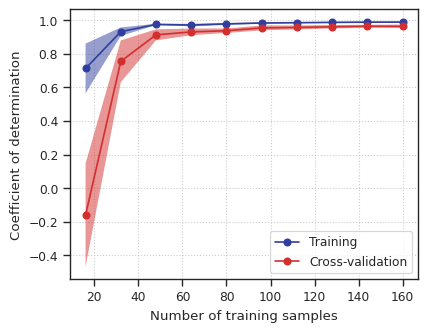

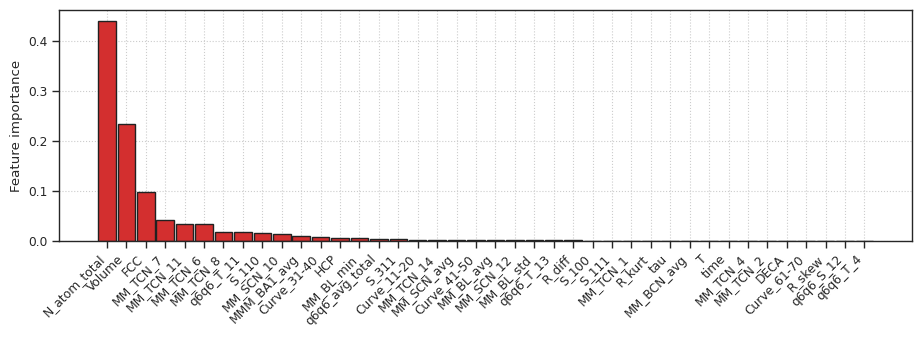

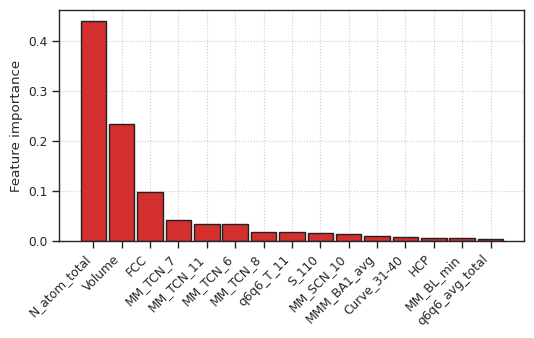

Removing the features with null values...
  Original number of features: 56
  Total number of features left: 56

Applying minmax scaling to feature values...
Applying minmax scaling to feature values...

Dataset: MNP
  Running LRR
  Trained and tested using Coefficient of determination.
    Training score: 0.977
    Cross-validation score: 0.927 +/- 0.023
    Testing score:
      Mean absolute error: 218.083108
      Mean squared error: 116683.597505
      Root mean squared error: 341.589809
      Coefficient of determination: 0.928


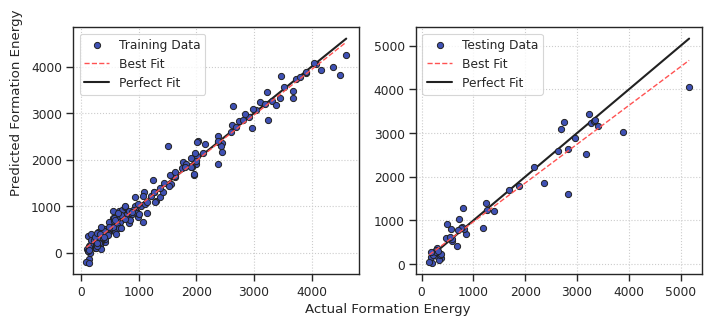

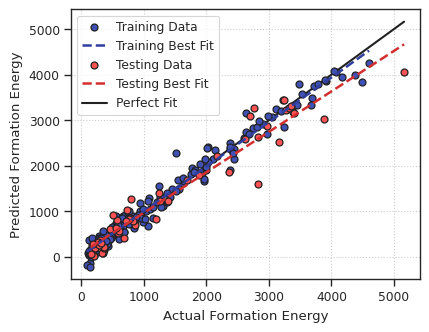

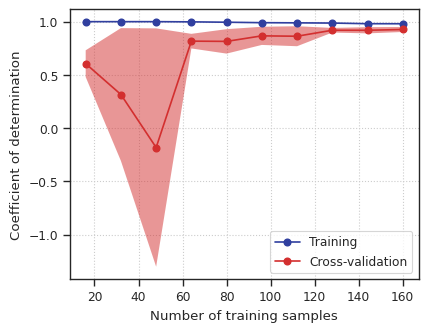

  Feature coefficients:
    T: 434.849
    N_atom_total: 6918.280
    R_diff: 43.028
    R_skew: 193.970
    S_111: 91.930
    S_110: 1327.636
    Curve_41-50: 158.332
    MM_BCN_avg: 379.415
    MM_SCN_avg: 120.357
    MM_TCN_1: 85.532
    MM_TCN_2: 46.669
    MM_TCN_4: 565.762
    MM_TCN_6: 4097.594
    MM_TCN_7: 2057.203
    MM_TCN_8: 3849.676
    MM_SCN_10: 350.289
    MM_SCN_13: 94.273
    MM_SCN_14: 99.766
    MM_SCN_15: 206.988
    MM_BL_min: 144.935
    MMM_BA1_avg: 282.327
    ICOS: 6.588
    DECA: 455.334
    q6q6_S_13: 40.204

Dataset: MNP
Best score: 0.854
Best parameter combination: {'criterion': 'friedman_mse', 'max_depth': 4, 'max_features': np.float64(0.9556428757689246), 'max_leaf_nodes': 76, 'min_samples_leaf': 5, 'min_samples_split': 8, 'n_estimators': 85}
  Running RFR
  Trained and tested using Coefficient of determination.
    Training score: 0.959
    Cross-validation score: 0.854 +/- 0.079
    Testing score:
      Mean absolute error: 255.365412
      Mean squar

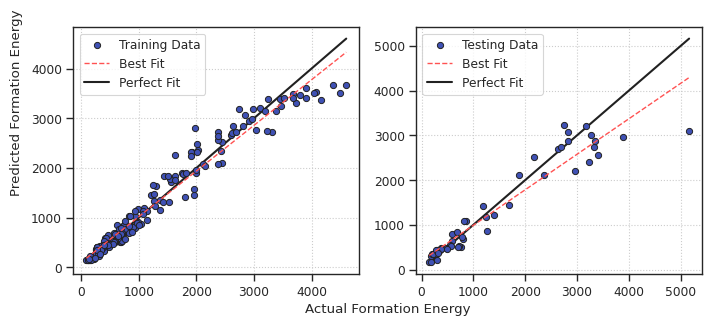

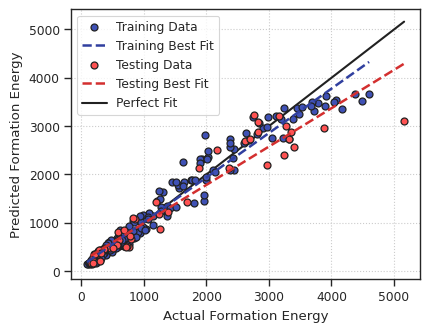

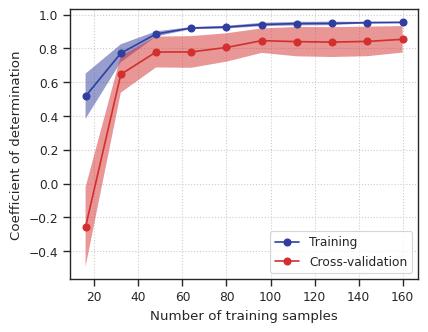

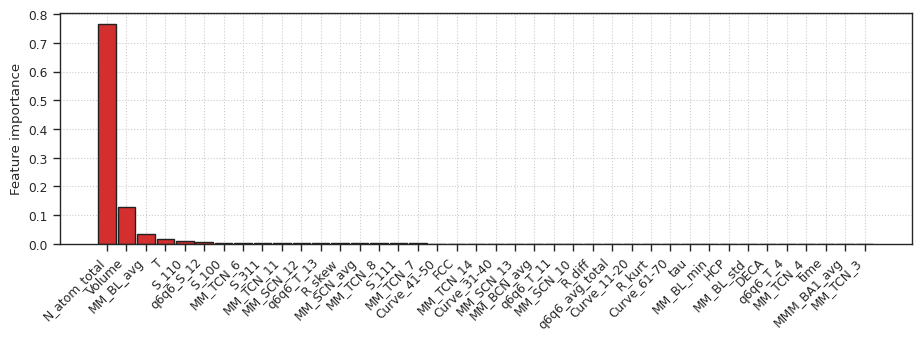

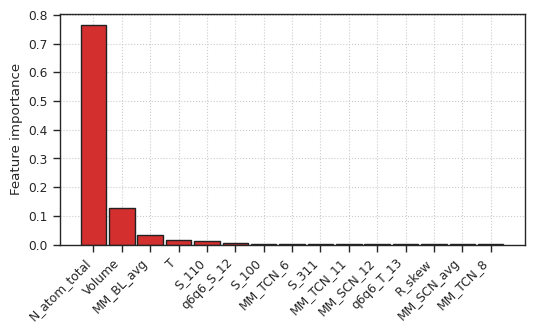

In [ ]:
for label in ('Total_E', 'Formation_E'):
    FIG_NAME_APPENDIX = f"red_{label_dict[label]['label']}_minmax"

    # Data loading
    MNPDF = pd.read_pickle(f"{DATA_DIR}/processed/processedRedMNPEdataNoC{int(CORR_THRESH * 100)}.pkl")
    other_label = 'Formation_E' if label == 'Total_E' else 'Total_E'
    MNPDF = MNPDF.drop([other_label], axis=1)
    
    MNPNoNullDF = rmNullFeats(featsDF=MNPDF, verbose=VERBOSE)
    
    XtrainMNP, XtestMNP, yTrainMNP, yTestMNP = splitScaleData(df=MNPDF, polyFeats=POLY_FEATS, scaling=SCALING, verbose=VERBOSE)
    XtrainMNPNoNull, XtestMNPNoNull, yTrainMNPNoNull, yTestMNPNoNull = splitScaleData(df=MNPNoNullDF, polyFeats=POLY_FEATS, scaling=SCALING, verbose=VERBOSE)
    
    X_Y_MNPS = {'WithNull': {'MNP': (XtrainMNP, XtestMNP, yTrainMNP, yTestMNP)}, 
                'NoNull': {'MNP': (XtrainMNPNoNull, XtestMNPNoNull, yTrainMNPNoNull, yTestMNPNoNull)}}

    # Linear Regression
    hasMissingVals, modelName = 'NoNull', 'LRR'
    for mnp in X_Y_MNPS[hasMissingVals].keys():
        print(f"\nDataset: {mnp}")
        Xtrain, Xtest, yTrain, yTest = X_Y_MNPS[hasMissingVals][mnp]
        
        linReg = LinearRegression(positive=False, fit_intercept=True, 
                                  copy_X=True, n_jobs=NUM_JOBS)  # No speedup from n_jobs here as n_target=1 and positive=False
        cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
        yPredTrainLinR, yPredTestLinR, linReg = runModel(Xtrain, yTrain, Xtest, yTest, cv,
                                                         model=linReg, modelName=modelName, datasetName=mnp, figNameAppendix=FIG_NAME_APPENDIX,
                                                         numFeat=20, isReg=True, label=label_dict[label]['name'], showFeatCoef=True, plotFeatImp=False, verbose=True, showFig=True)

    # Random Forest
    hasMissingVals, modelName = 'WithNull', 'RFR'
    for mnp in X_Y_MNPS[hasMissingVals].keys():
        print(f"\nDataset: {mnp}")
        if exists(f"{DATA_DIR}/hpTune/hpTune{mnp}{modelName}_{FIG_NAME_APPENDIX}.pkl"):
            print('Already done, skipping...')
            continue
        Xtrain, Xtest, yTrain, yTest = X_Y_MNPS[hasMissingVals][mnp]
    
        rfReg = RandomForestRegressor(n_estimators=5, criterion='squared_error', max_depth=None, 
                                      max_features=1.0, max_leaf_nodes=None, min_samples_split=2, min_samples_leaf=1, 
                                      min_impurity_decrease=0.0, min_weight_fraction_leaf=0.0, n_jobs=NUM_JOBS, random_state=RANDOM_SEED, verbose=0, 
                                      bootstrap=True, oob_score=False, warm_start=False, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)
        paramGrid = {'criterion': ['squared_error', 'absolute_error', 'friedman_mse'], 
                     'n_estimators': stats.randint(low=3, high=100), 
                     'max_depth' : stats.randint(low=1, high=10), 
                     'max_features': stats.uniform(loc=0.1, scale=0.9), 
                     'max_leaf_nodes': stats.randint(low=5, high=100),
                     'min_samples_split': stats.randint(low=2, high=20), 
                     'min_samples_leaf': stats.randint(low=1, high=10)}
        cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
        searchResults = hyperparamTune(rfReg, paramGrid, Xtrain, yTrain, scoringMetric='r2', cv=cv, numIter=2)
        with open(f"{DATA_DIR}/hpTune/hpTune{mnp}{modelName}_{FIG_NAME_APPENDIX}.pkl", 'wb') as f:
            pickle.dump(searchResults, f)
    
        rfReg = searchResults.best_estimator_
        yPredTrainRFR, yPredTestRFR, rfReg = runModel(Xtrain, yTrain, Xtest, yTest, cv,
                                                      model=rfReg, modelName=modelName, datasetName=mnp, figNameAppendix=FIG_NAME_APPENDIX,
                                                      numFeat=15, label=label_dict[label]['name'], showFeatCoef=False, plotFeatImp=True, verbose=True, showFig=True)
        # Note: Set 'showFig' to False for cluster jobs!

### Reduced dataset with random samples

Removing the features with null values...
  Original number of features: 77
  Total number of features left: 77

Removing the features with null values...
  Original number of features: 77
  Total number of features left: 77

Applying minmax scaling to feature values...
Applying minmax scaling to feature values...

Dataset: MNP
  Running LRR
  Trained and tested using Coefficient of determination.
    Training score: 0.531
    Cross-validation score: 0.223 +/- 0.210
    Testing score:
      Mean absolute error: 0.015850
      Mean squared error: 0.000528
      Root mean squared error: 0.022974
      Coefficient of determination: 0.344


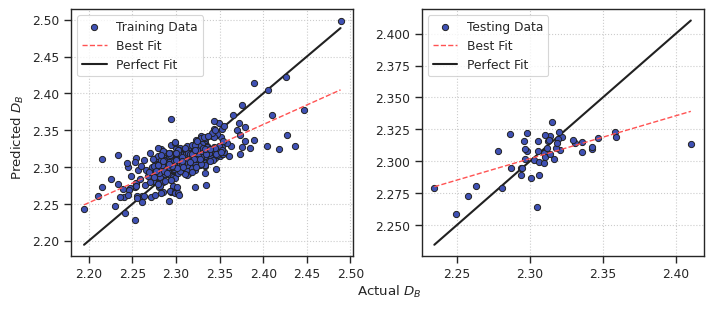

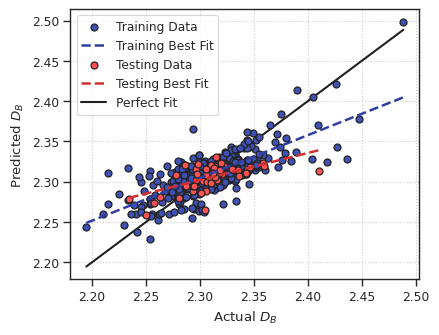

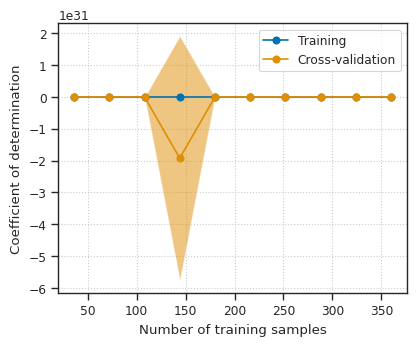

  Feature coefficients:
    time: 0.001
    q6q6_avg_surf: 0.004
    R_skew: 0.029
    MM_TCN_avg: 0.065
    MM_BL_avg: 0.010
    MM_BL_min: 0.007
    Curve_61-70: 0.001
    MM_SCN_3: 0.001
    MM_SCN_15: 0.019
    q6q6_S_8: 0.059
    MM_TCN_16: 0.003
    MM_TCN_17: 0.016
    MM_BCN_5: 0.004
    MM_BCN_9: 0.001
    q6q6_B_8: 0.059

Dataset: MNP
Best score: 0.500
Best parameter combination: {'criterion': 'squared_error', 'max_depth': 9, 'max_features': 0.38547614508885875, 'max_leaf_nodes': 79, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 91}
  Running RFR
  Trained and tested using Coefficient of determination.
    Training score: 0.826
    Cross-validation score: 0.500 +/- 0.052
    Testing score:
      Mean absolute error: 0.014348
      Mean squared error: 0.000624
      Root mean squared error: 0.024978
      Coefficient of determination: 0.225


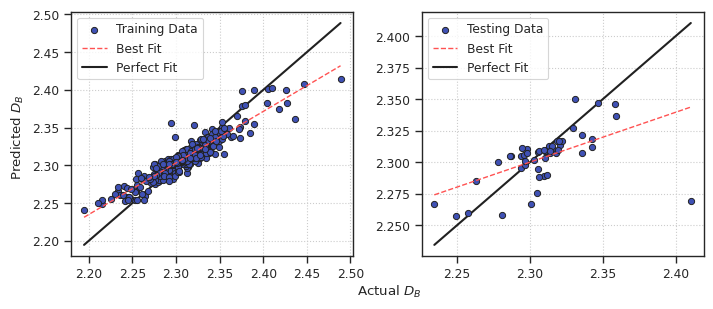

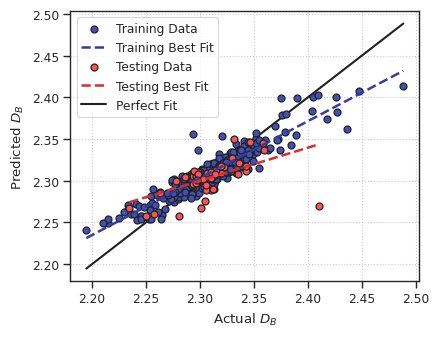

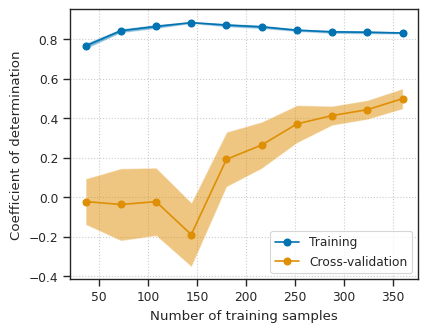

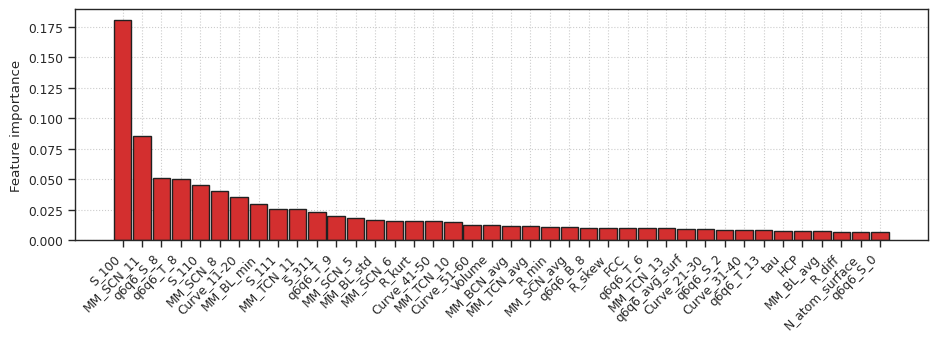

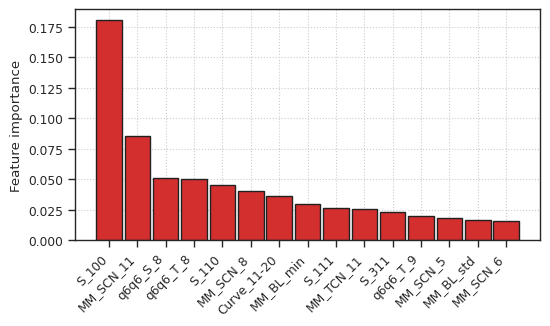

Removing the features with null values...
  Original number of features: 75
  Total number of features left: 75

Removing the features with null values...
  Original number of features: 75
  Total number of features left: 75

Applying minmax scaling to feature values...
Applying minmax scaling to feature values...

Dataset: MNP
  Running LRR
  Trained and tested using Coefficient of determination.
    Training score: 0.406
    Cross-validation score: 0.290 +/- 0.078
    Testing score:
      Mean absolute error: 0.019855
      Mean squared error: 0.000673
      Root mean squared error: 0.025943
      Coefficient of determination: 0.295


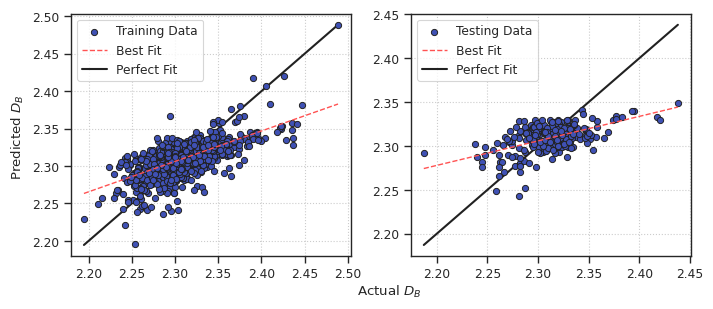

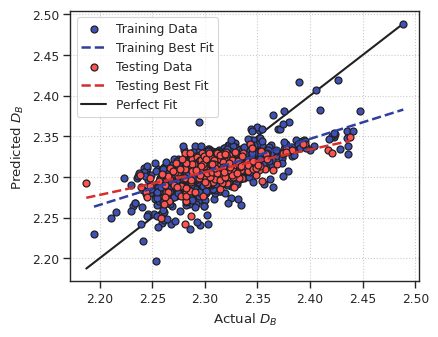

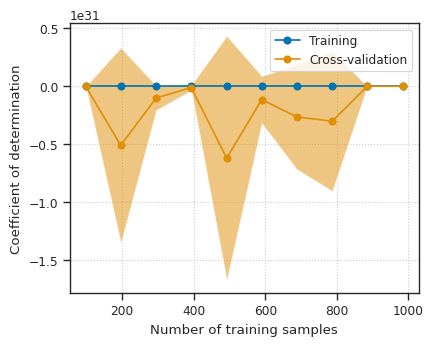

  Feature coefficients:
    time: 0.001
    q6q6_avg_surf: 0.005
    R_diff: 0.008
    MM_TCN_avg: 0.111
    MM_BCN_avg: 0.006
    MM_BL_avg: 0.008
    MM_BL_min: 0.007
    Curve_51-60: 0.001
    Curve_61-70: 0.001
    MM_SCN_3: 0.001
    MM_SCN_14: 0.003
    MM_SCN_15: 0.015
    MM_TCN_16: 0.004
    MM_TCN_17: 0.003
    q6q6_T_8: 0.068

Dataset: MNP
Best score: 0.633
Best parameter combination: {'criterion': 'squared_error', 'max_depth': 9, 'max_features': 0.9257887086883703, 'max_leaf_nodes': 75, 'min_samples_leaf': 6, 'min_samples_split': 3, 'n_estimators': 43}
  Running RFR
  Trained and tested using Coefficient of determination.
    Training score: 0.834
    Cross-validation score: 0.633 +/- 0.026
    Testing score:
      Mean absolute error: 0.013056
      Mean squared error: 0.000338
      Root mean squared error: 0.018375
      Coefficient of determination: 0.646


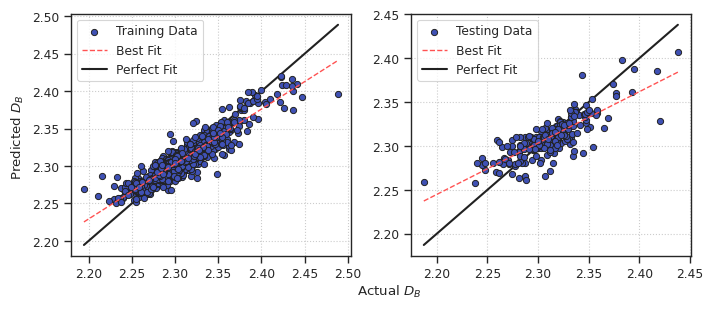

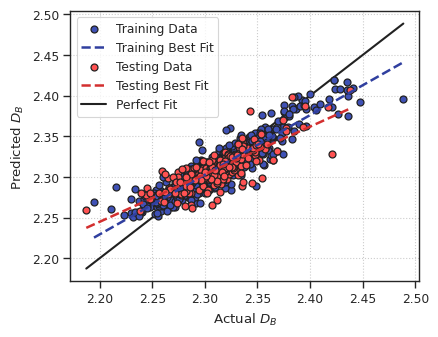

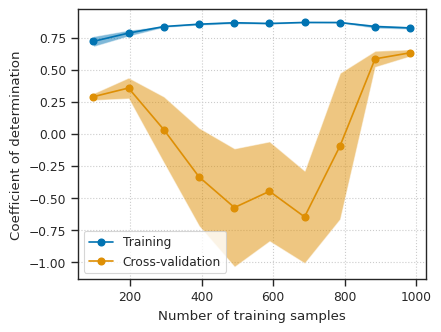

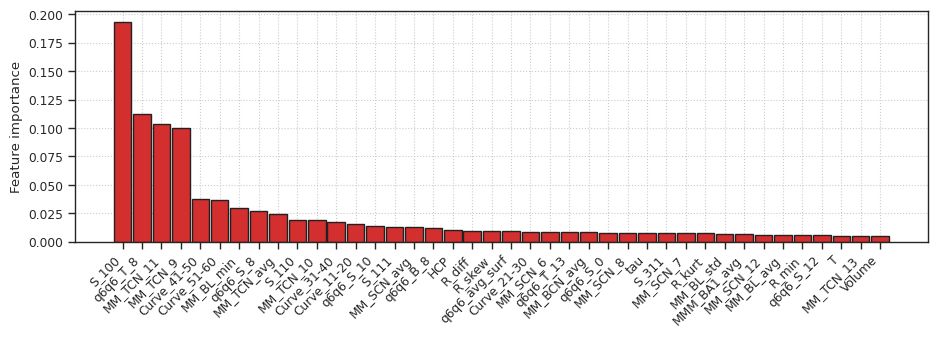

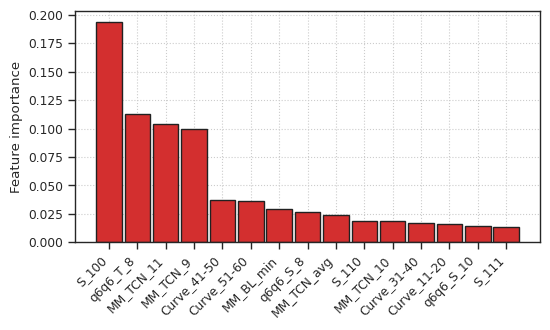

Removing the features with null values...
  Original number of features: 75
  Total number of features left: 75

Removing the features with null values...
  Original number of features: 75
  Total number of features left: 75

Applying minmax scaling to feature values...
Applying minmax scaling to feature values...

Dataset: MNP
  Running LRR
  Trained and tested using Coefficient of determination.
    Training score: 0.446
    Cross-validation score: 0.366 +/- 0.056
    Testing score:
      Mean absolute error: 0.017734
      Mean squared error: 0.000604
      Root mean squared error: 0.024570
      Coefficient of determination: 0.431


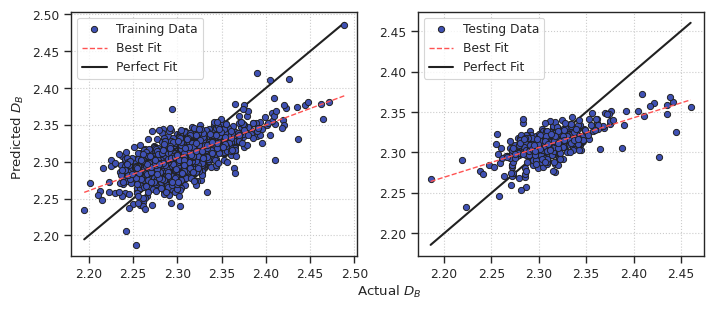

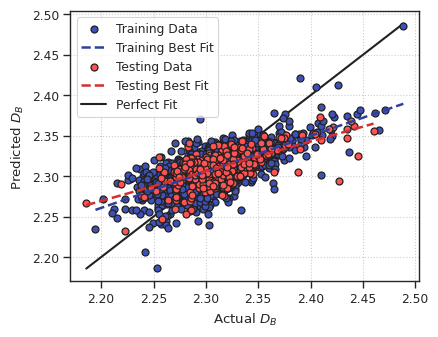

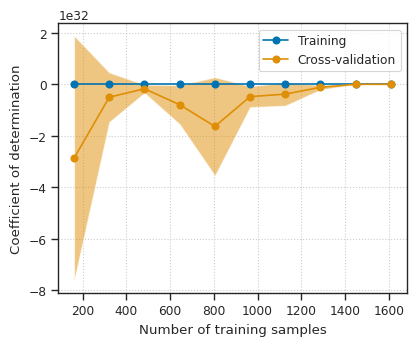

  Feature coefficients:
    time: 0.002
    q6q6_avg_surf: 0.004
    N_atom_surface: 0.022
    R_diff: 0.038
    R_min: 0.015
    MM_TCN_avg: 0.111
    MM_BCN_avg: 0.001
    MM_BL_avg: 0.005
    MM_BL_std: 0.002
    MM_BL_min: 0.004
    ICOS: 0.002
    MM_SCN_12: 0.001
    MM_SCN_13: 0.002
    MM_SCN_15: 0.005
    MM_TCN_16: 0.007
    MM_TCN_17: 0.010
    q6q6_T_10: 0.091
    MM_BCN_5: 0.001
    MM_BCN_6: 0.001
    MM_BCN_7: 0.002
    MM_BCN_8: 0.001
    MM_BCN_9: 0.001

Dataset: MNP
Best score: 0.631
Best parameter combination: {'criterion': 'squared_error', 'max_depth': 9, 'max_features': 0.38547614508885875, 'max_leaf_nodes': 79, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 91}
  Running RFR
  Trained and tested using Coefficient of determination.
    Training score: 0.824
    Cross-validation score: 0.631 +/- 0.029
    Testing score:
      Mean absolute error: 0.012523
      Mean squared error: 0.000363
      Root mean squared error: 0.019056
      Coefficient of 

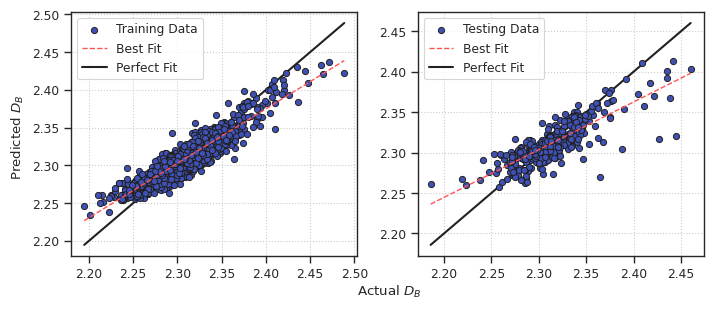

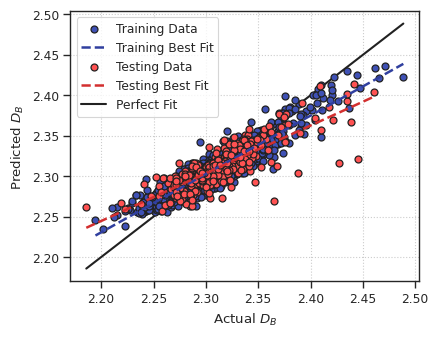

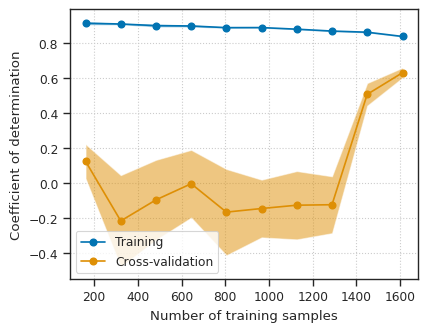

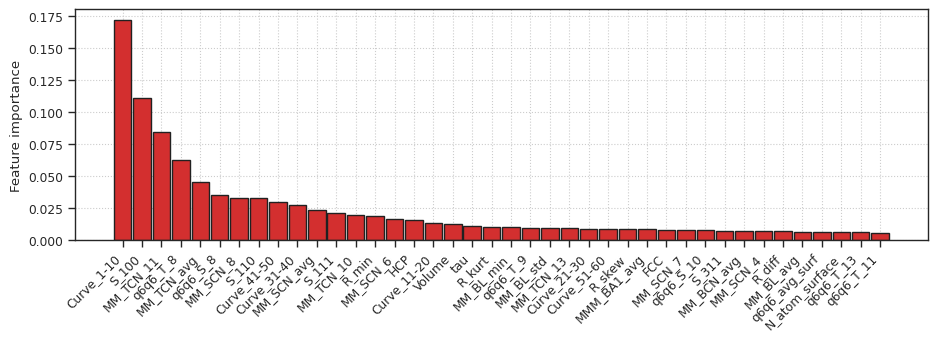

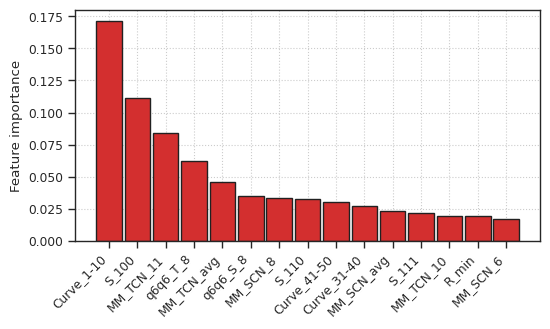

Removing the features with null values...
  Original number of features: 76
  Total number of features left: 76

Removing the features with null values...
  Original number of features: 76
  Total number of features left: 76

Applying minmax scaling to feature values...
Applying minmax scaling to feature values...

Dataset: MNP
  Running LRR
  Trained and tested using Coefficient of determination.
    Training score: 0.449
    Cross-validation score: 0.348 +/- 0.075
    Testing score:
      Mean absolute error: 0.017224
      Mean squared error: 0.000534
      Root mean squared error: 0.023108
      Coefficient of determination: 0.461


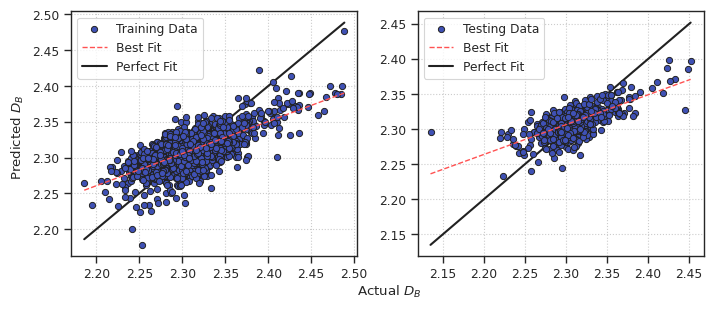

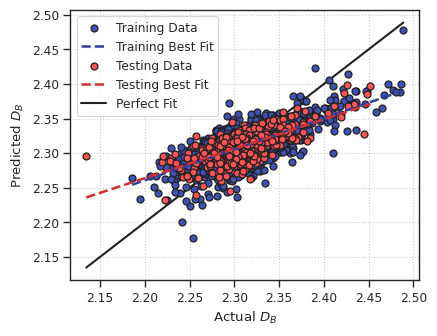

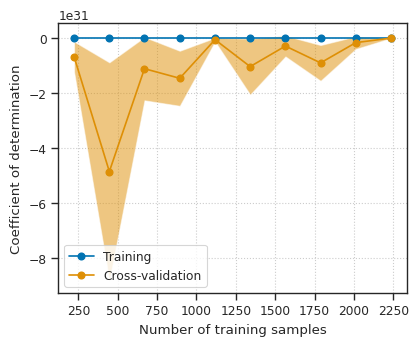

  Feature coefficients:
    time: 0.002
    q6q6_avg_surf: 0.003
    N_atom_surface: 0.029
    R_diff: 0.057
    R_min: 0.050
    MM_TCN_avg: 0.118
    MM_BCN_avg: 0.013
    MM_BL_avg: 0.003
    MM_BL_std: 0.006
    MM_SCN_12: 0.001
    MM_SCN_13: 0.002
    MM_SCN_14: 0.004
    MM_SCN_15: 0.005
    q6q6_S_8: 0.149
    MM_TCN_16: 0.005
    MM_TCN_17: 0.001
    q6q6_T_10: 0.486
    MM_BCN_6: 0.005
    MM_BCN_7: 0.002
    MM_BCN_8: 0.001
    MM_BCN_9: 0.001
    q6q6_B_8: 0.149

Dataset: MNP
Best score: 0.660
Best parameter combination: {'criterion': 'squared_error', 'max_depth': 9, 'max_features': 0.38547614508885875, 'max_leaf_nodes': 79, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 91}
  Running RFR
  Trained and tested using Coefficient of determination.
    Training score: 0.813
    Cross-validation score: 0.660 +/- 0.036
    Testing score:
      Mean absolute error: 0.011955
      Mean squared error: 0.000280
      Root mean squared error: 0.016732
      Coefficient

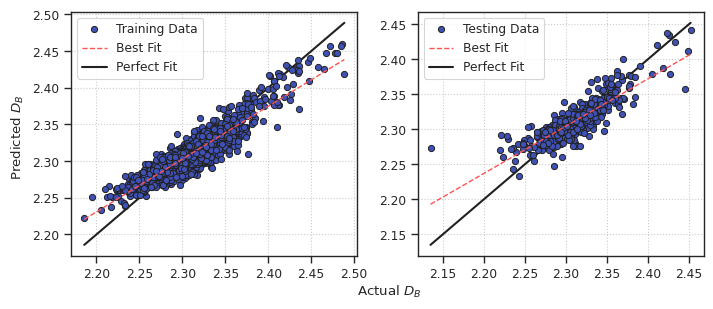

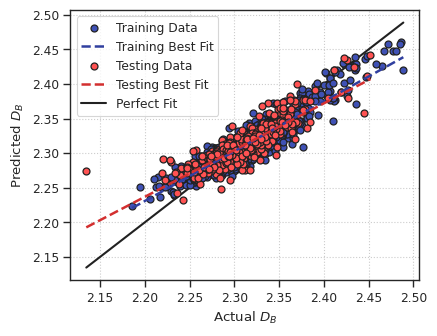

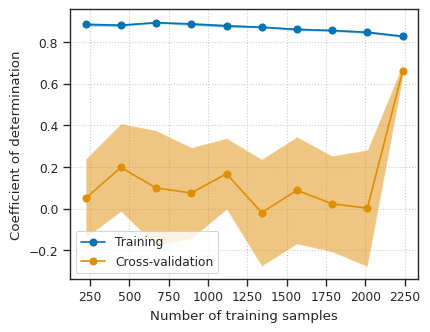

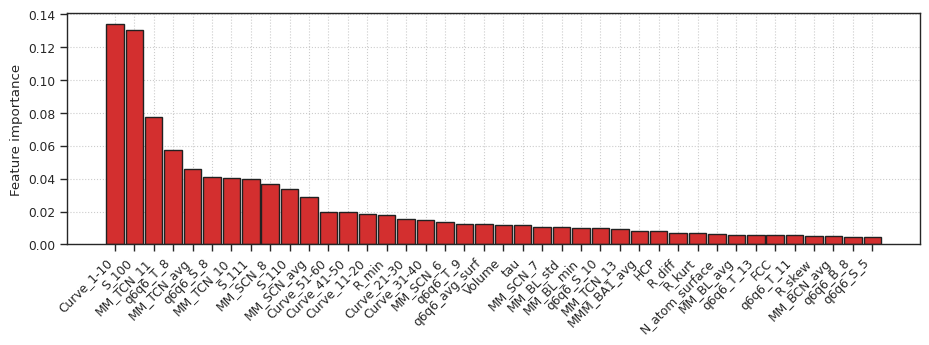

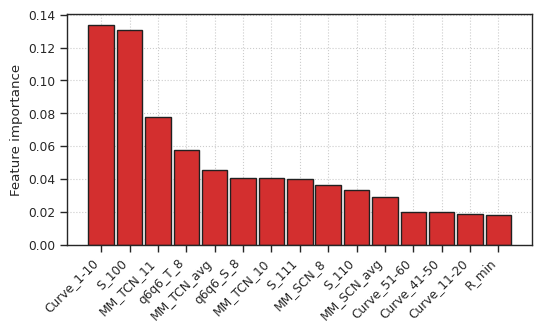

Removing the features with null values...
  Original number of features: 75
  Total number of features left: 75

Removing the features with null values...
  Original number of features: 75
  Total number of features left: 75

Applying minmax scaling to feature values...
Applying minmax scaling to feature values...

Dataset: MNP
  Running LRR
  Trained and tested using Coefficient of determination.
    Training score: 0.453
    Cross-validation score: 0.361 +/- 0.071
    Testing score:
      Mean absolute error: 0.017411
      Mean squared error: 0.000516
      Root mean squared error: 0.022710
      Coefficient of determination: 0.421


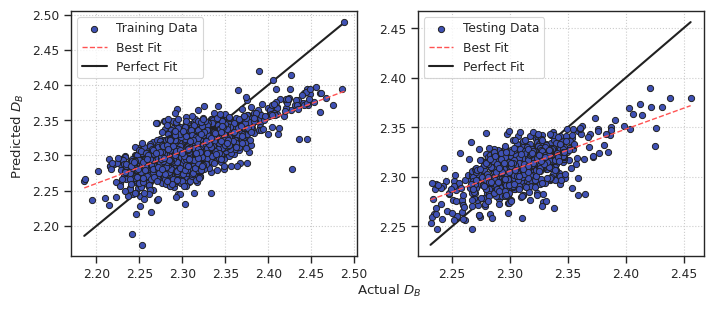

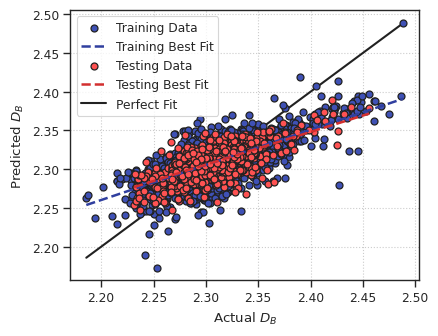

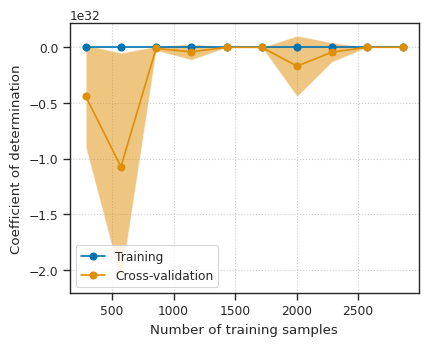

  Feature coefficients:
    time: 0.002
    q6q6_avg_surf: 0.001
    N_atom_surface: 0.037
    R_diff: 0.053
    R_min: 0.017
    MM_TCN_avg: 0.143
    MM_BL_avg: 0.009
    MM_BL_min: 0.004
    ICOS: 0.003
    MM_SCN_12: 0.001
    MM_SCN_13: 0.002
    MM_SCN_14: 0.006
    MM_TCN_16: 0.009
    MM_TCN_17: 0.001
    MM_BCN_8: 0.004

Dataset: MNP
Best score: 0.695
Best parameter combination: {'criterion': 'squared_error', 'max_depth': 9, 'max_features': 0.9274486641154054, 'max_leaf_nodes': 91, 'min_samples_leaf': 7, 'min_samples_split': 7, 'n_estimators': 84}
  Running RFR
  Trained and tested using Coefficient of determination.
    Training score: 0.813
    Cross-validation score: 0.695 +/- 0.038
    Testing score:
      Mean absolute error: 0.011492
      Mean squared error: 0.000247
      Root mean squared error: 0.015727
      Coefficient of determination: 0.722


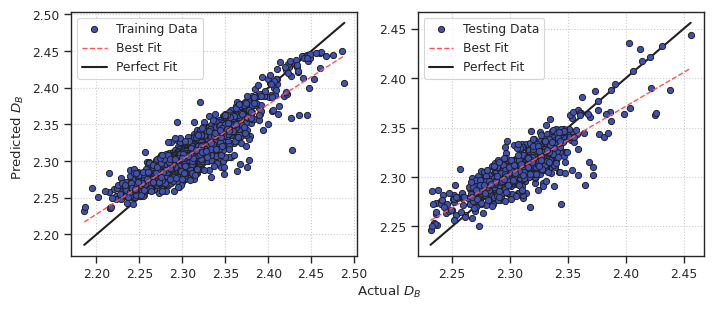

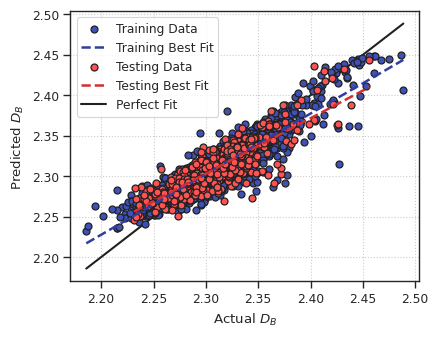

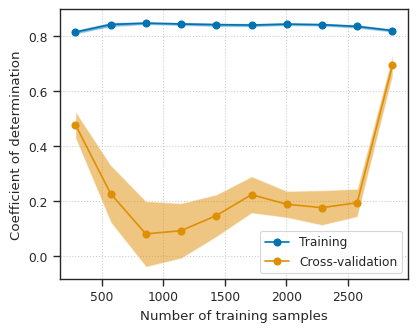

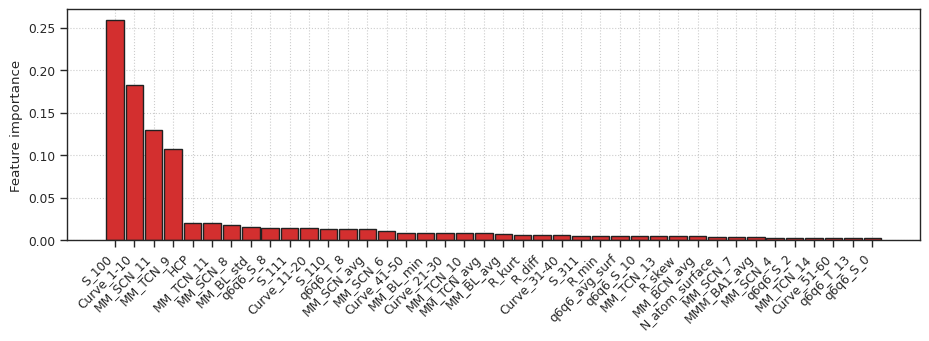

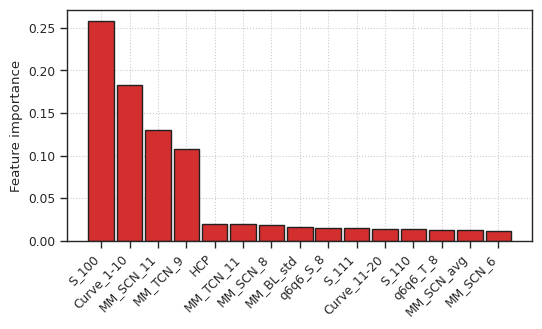

Removing the features with null values...
  Original number of features: 75
  Total number of features left: 75

Removing the features with null values...
  Original number of features: 75
  Total number of features left: 75

Applying minmax scaling to feature values...
Applying minmax scaling to feature values...

Dataset: MNP
  Running LRR
  Trained and tested using Coefficient of determination.
    Training score: 0.457
    Cross-validation score: 0.388 +/- 0.013
    Testing score:
      Mean absolute error: 0.017022
      Mean squared error: 0.000507
      Root mean squared error: 0.022510
      Coefficient of determination: 0.476


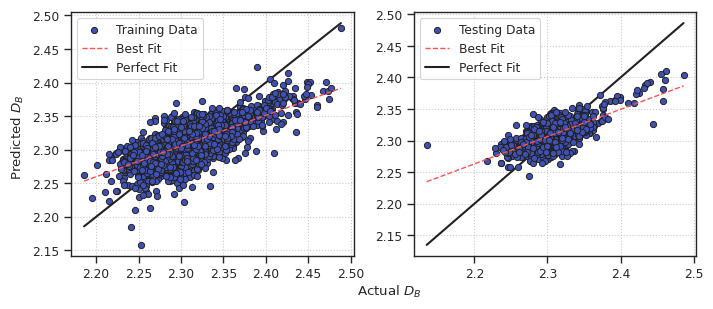

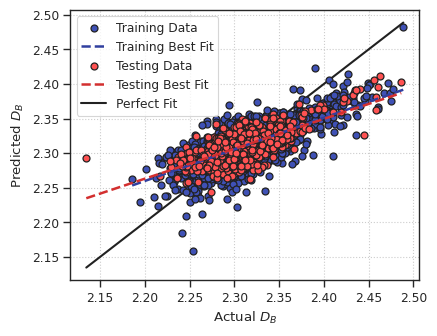

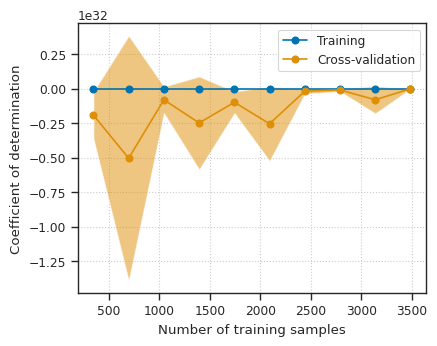

  Feature coefficients:
    time: 0.002
    q6q6_avg_surf: 0.001
    N_atom_surface: 0.033
    R_diff: 0.057
    R_min: 0.033
    MM_TCN_avg: 0.155
    MM_BCN_avg: 0.004
    MM_BL_avg: 0.008
    MM_BL_min: 0.003
    ICOS: 0.004
    MM_SCN_2: 0.001
    MM_SCN_12: 0.001
    MM_SCN_13: 0.002
    MM_SCN_14: 0.008
    MM_TCN_16: 0.006
    q6q6_T_10: 0.229
    MM_BCN_7: 0.003
    MM_BCN_8: 0.005

Dataset: MNP
Best score: 0.710
Best parameter combination: {'criterion': 'squared_error', 'max_depth': 9, 'max_features': 0.9274486641154054, 'max_leaf_nodes': 91, 'min_samples_leaf': 7, 'min_samples_split': 7, 'n_estimators': 84}
  Running RFR
  Trained and tested using Coefficient of determination.
    Training score: 0.810
    Cross-validation score: 0.710 +/- 0.031
    Testing score:
      Mean absolute error: 0.011546
      Mean squared error: 0.000254
      Root mean squared error: 0.015941
      Coefficient of determination: 0.737


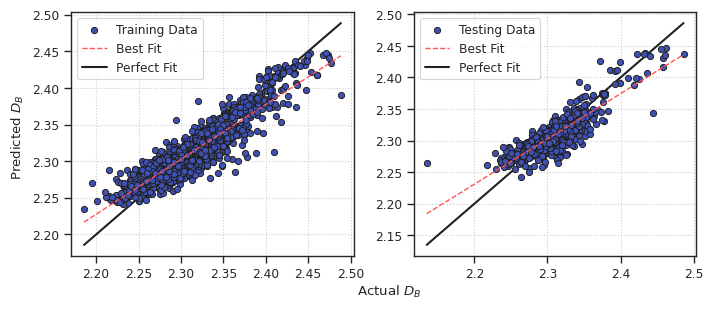

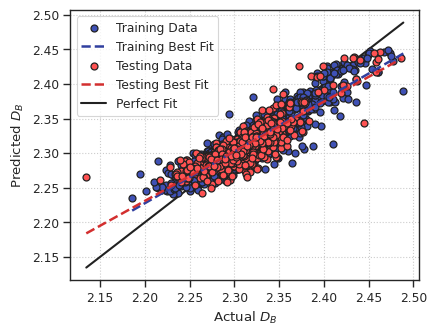

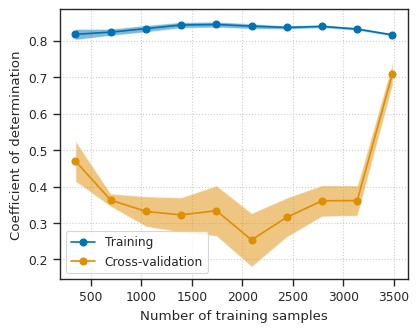

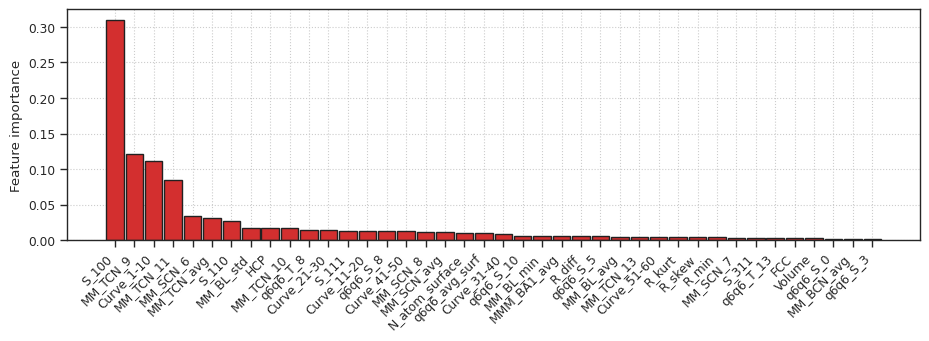

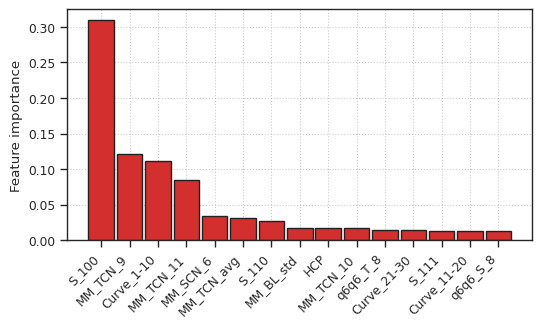

Removing the features with null values...
  Original number of features: 76
  Total number of features left: 76

Removing the features with null values...
  Original number of features: 76
  Total number of features left: 76

Applying minmax scaling to feature values...
Applying minmax scaling to feature values...

Dataset: MNP
  Running LRR
  Trained and tested using Coefficient of determination.
    Training score: 0.461
    Cross-validation score: 0.390 +/- 0.043
    Testing score:
      Mean absolute error: 0.017495
      Mean squared error: 0.000513
      Root mean squared error: 0.022650
      Coefficient of determination: 0.470


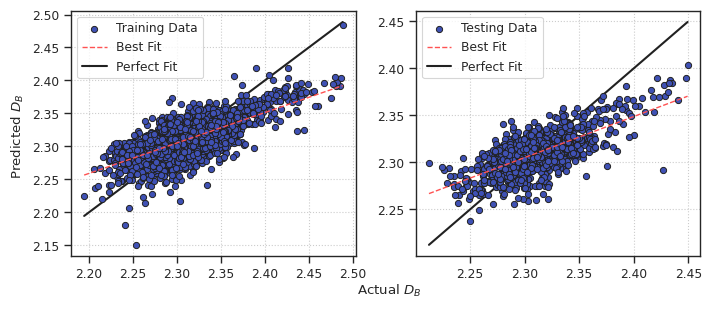

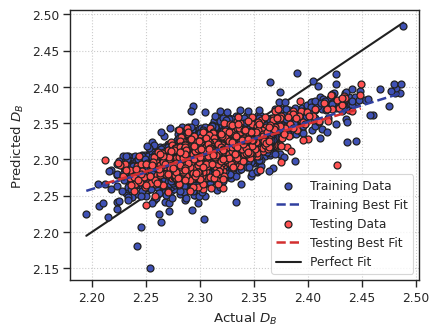

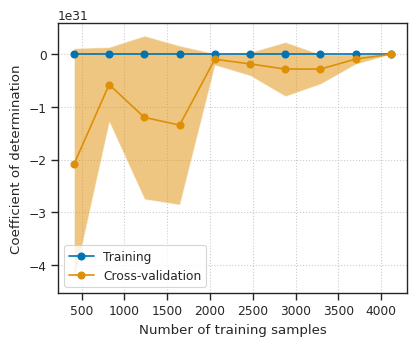

  Feature coefficients:
    time: 0.003
    q6q6_avg_surf: 0.001
    N_atom_surface: 0.035
    R_diff: 0.065
    R_min: 0.042
    MM_TCN_avg: 0.154
    MM_BCN_avg: 0.007
    MM_BL_avg: 0.006
    MM_BL_std: 0.002
    MM_BL_min: 0.003
    ICOS: 0.003
    MM_SCN_12: 0.001
    MM_SCN_13: 0.003
    MM_SCN_14: 0.006
    MM_SCN_15: 0.004
    MM_TCN_16: 0.006
    MM_TCN_17: 0.002
    q6q6_T_10: 0.131
    MM_BCN_7: 0.006
    MM_BCN_8: 0.006

Dataset: MNP
Best score: 0.710
Best parameter combination: {'criterion': 'squared_error', 'max_depth': 9, 'max_features': 0.9463772865706722, 'max_leaf_nodes': 94, 'min_samples_leaf': 5, 'min_samples_split': 19, 'n_estimators': 79}
  Running RFR
  Trained and tested using Coefficient of determination.
    Training score: 0.806
    Cross-validation score: 0.710 +/- 0.022
    Testing score:
      Mean absolute error: 0.011731
      Mean squared error: 0.000262
      Root mean squared error: 0.016194
      Coefficient of determination: 0.729


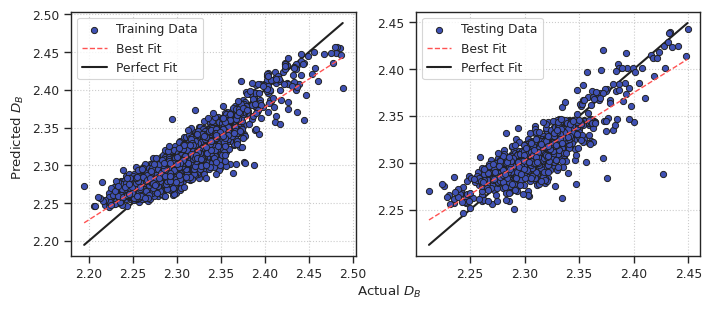

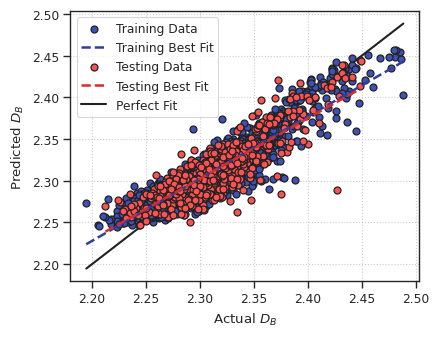

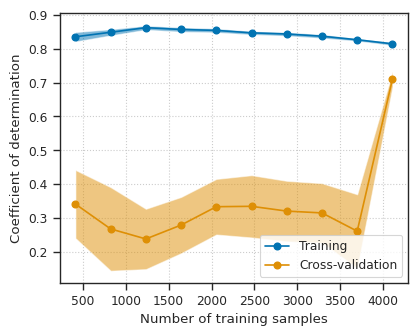

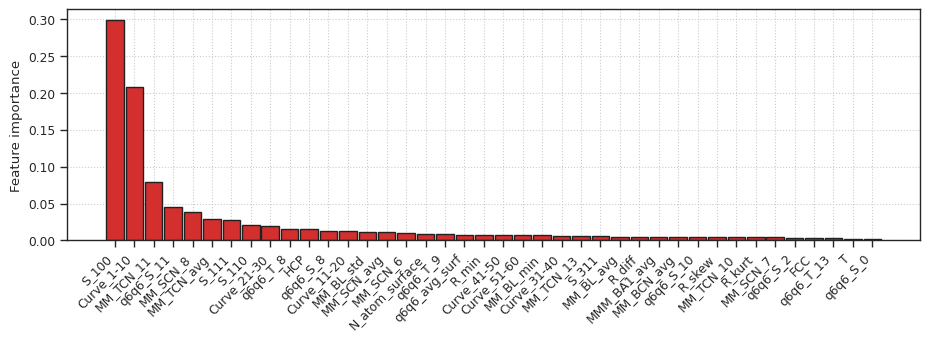

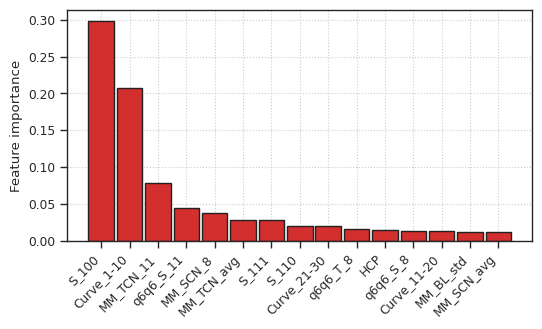

Removing the features with null values...
  Original number of features: 75
  Total number of features left: 75

Removing the features with null values...
  Original number of features: 75
  Total number of features left: 75

Applying minmax scaling to feature values...
Applying minmax scaling to feature values...

Dataset: MNP
  Running LRR
  Trained and tested using Coefficient of determination.
    Training score: 0.444
    Cross-validation score: 0.392 +/- 0.026
    Testing score:
      Mean absolute error: 0.017668
      Mean squared error: 0.000534
      Root mean squared error: 0.023103
      Coefficient of determination: 0.421


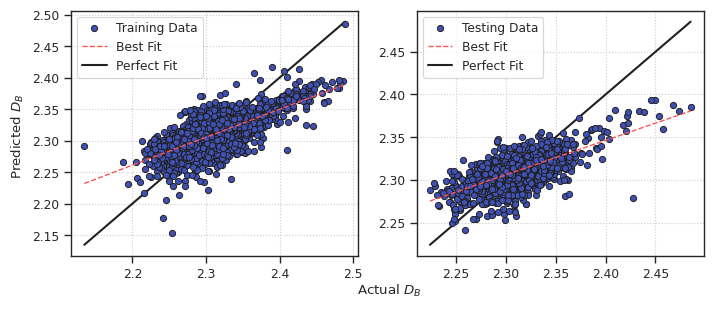

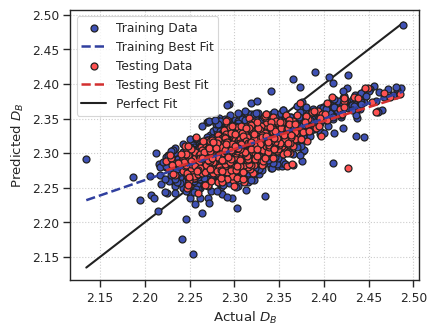

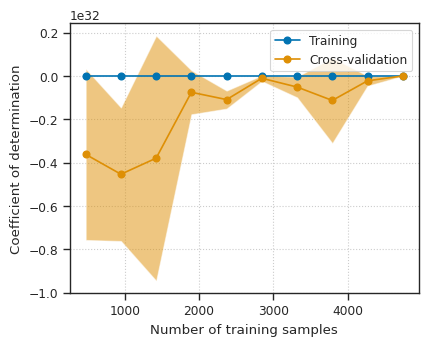

  Feature coefficients:
    time: 0.002
    N_atom_surface: 0.041
    R_diff: 0.059
    R_min: 0.020
    MM_TCN_avg: 0.164
    MM_BL_avg: 0.008
    MM_BL_min: 0.004
    ICOS: 0.006
    MM_SCN_2: 0.001
    MM_SCN_12: 0.001
    MM_SCN_13: 0.004
    MM_SCN_14: 0.007
    MM_TCN_16: 0.010
    MM_TCN_17: 0.001
    MM_BCN_6: 0.003
    MM_BCN_7: 0.001
    MM_BCN_8: 0.007

Dataset: MNP
Best score: 0.705
Best parameter combination: {'criterion': 'squared_error', 'max_depth': 9, 'max_features': 0.9274486641154054, 'max_leaf_nodes': 91, 'min_samples_leaf': 7, 'min_samples_split': 7, 'n_estimators': 84}
  Running RFR
  Trained and tested using Coefficient of determination.
    Training score: 0.793
    Cross-validation score: 0.705 +/- 0.018
    Testing score:
      Mean absolute error: 0.011835
      Mean squared error: 0.000263
      Root mean squared error: 0.016223
      Coefficient of determination: 0.715


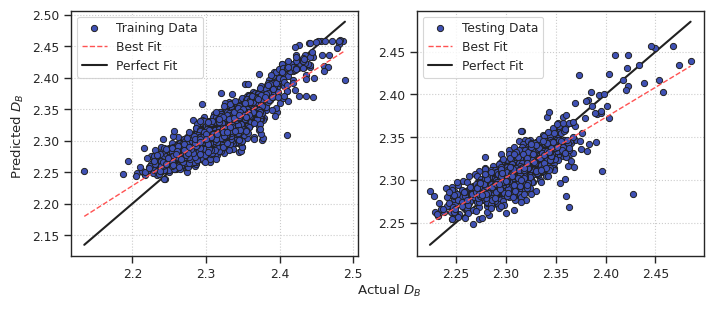

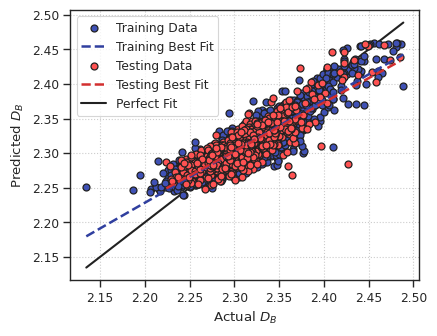

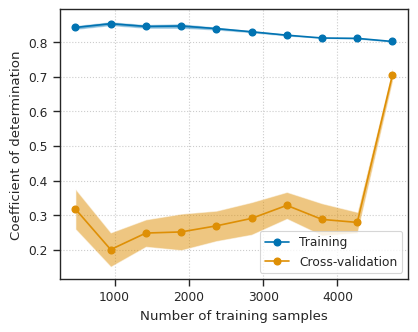

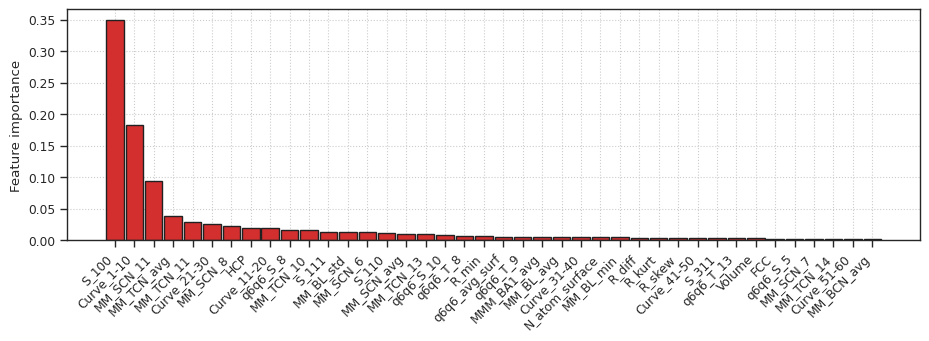

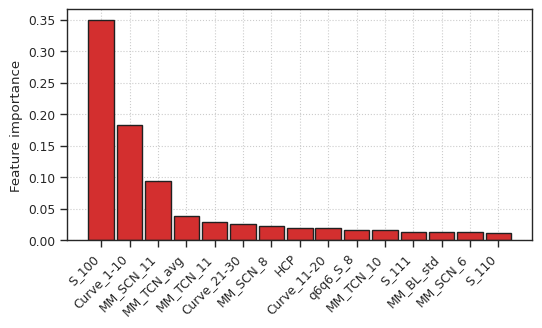

Removing the features with null values...
  Original number of features: 75
  Total number of features left: 75

Removing the features with null values...
  Original number of features: 75
  Total number of features left: 75

Applying minmax scaling to feature values...
Applying minmax scaling to feature values...

Dataset: MNP
  Running LRR
  Trained and tested using Coefficient of determination.
    Training score: 0.384
    Cross-validation score: 0.246 +/- 0.120
    Testing score:
      Mean absolute error: 0.017827
      Mean squared error: 0.000540
      Root mean squared error: 0.023228
      Coefficient of determination: 0.377


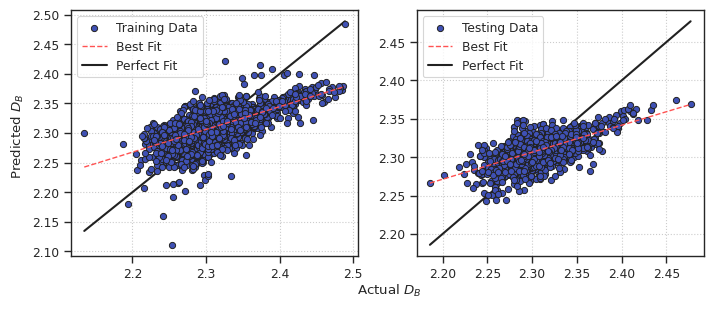

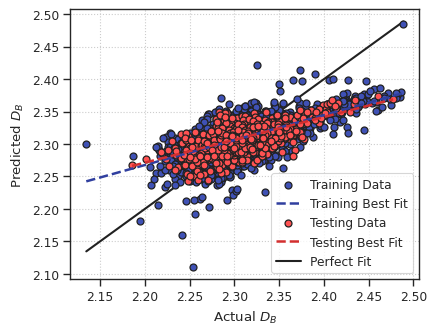

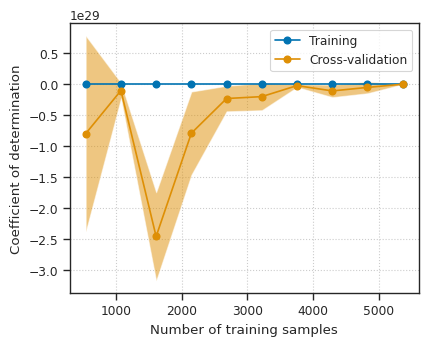

  Feature coefficients:
    time: 0.001
    q6q6_avg_surf: 0.008
    N_atom_surface: 0.004
    Volume: 0.003
    R_diff: 0.026
    R_skew: 0.002
    MM_TCN_avg: 0.204
    MM_BCN_avg: 0.002
    MM_BL_avg: 0.010
    MM_BL_std: 0.004
    MM_BL_min: 0.012
    MM_SCN_13: 0.002
    MM_SCN_15: 0.010
    q6q6_S_3: 0.001
    MM_TCN_16: 0.004
    q6q6_T_10: 0.246
    MM_BCN_9: 0.002

Dataset: MNP


In [ ]:
for label in ('Total_E', 'Formation_E'):
    for i in range(NUM_RUNS):
        FIG_NAME_APPENDIX = f"red_{label_dict[label]['label']}_run{i+1}_minmax"

        # Data loading
        MNPDF = pd.read_pickle(f"{DATA_DIR}/processedRedMNPdataNoC{int(CORR_THRESH * 100)}run{i+1}.pkl")
        other_label = 'Formation_E' if label == 'Total_E' else 'Total_E'
        MNPDF = MNPDF.drop([other_label], axis=1)
        
        MNPNoNullDF = rmNullFeats(featsDF=MNPDF, verbose=VERBOSE)
        
        XtrainMNP, XtestMNP, yTrainMNP, yTestMNP = splitScaleData(df=MNPDF, polyFeats=POLY_FEATS, scaling=SCALING, verbose=VERBOSE)
        XtrainMNPNoNull, XtestMNPNoNull, yTrainMNPNoNull, yTestMNPNoNull = splitScaleData(df=MNPNoNullDF, polyFeats=POLY_FEATS, scaling=SCALING, verbose=VERBOSE)
        
        X_Y_MNPS = {'WithNull': {'MNP': (XtrainMNP, XtestMNP, yTrainMNP, yTestMNP)}, 
                    'NoNull': {'MNP': (XtrainMNPNoNull, XtestMNPNoNull, yTrainMNPNoNull, yTestMNPNoNull)}}

        # Linear Regression
        hasMissingVals, modelName = 'NoNull', 'LRR'
        for mnp in X_Y_MNPS[hasMissingVals].keys():
            print(f"\nDataset: {mnp}")
            Xtrain, Xtest, yTrain, yTest = X_Y_MNPS[hasMissingVals][mnp]
            
            linReg = LinearRegression(positive=False, fit_intercept=True, 
                                    copy_X=True, n_jobs=NUM_JOBS)  # No speedup from n_jobs here as n_target=1 and positive=False
            cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
            yPredTrainLinR, yPredTestLinR, linReg = runModel(Xtrain, yTrain, Xtest, yTest, cv,
                                                            model=linReg, modelName=modelName, datasetName=mnp, figNameAppendix=FIG_NAME_APPENDIX,
                                                            numFeat=20, isReg=True, label=label_dict[label]['name'], showFeatCoef=True, plotFeatImp=False, verbose=True, showFig=True)

        # Random Forest
        hasMissingVals, modelName = 'WithNull', 'RFR'
        for mnp in X_Y_MNPS[hasMissingVals].keys():
            print(f"\nDataset: {mnp}")
            if exists(f"{DATA_DIR}/hpTune/hpTune{mnp}{modelName}_{FIG_NAME_APPENDIX}_run{i+1}.pkl"):
                print('Already done, skipping...')
                continue
            Xtrain, Xtest, yTrain, yTest = X_Y_MNPS[hasMissingVals][mnp]
        
            rfReg = RandomForestRegressor(n_estimators=5, criterion='squared_error', max_depth=None, 
                                        max_features=1.0, max_leaf_nodes=None, min_samples_split=2, min_samples_leaf=1, 
                                        min_impurity_decrease=0.0, min_weight_fraction_leaf=0.0, n_jobs=NUM_JOBS, random_state=RANDOM_SEED, verbose=0, 
                                        bootstrap=True, oob_score=False, warm_start=False, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)
            paramGrid = {'criterion': ['squared_error', 'absolute_error', 'friedman_mse'], 
                        'n_estimators': stats.randint(low=3, high=100), 
                        'max_depth' : stats.randint(low=1, high=10), 
                        'max_features': stats.uniform(loc=0.1, scale=0.9), 
                        'max_leaf_nodes': stats.randint(low=5, high=100),
                        'min_samples_split': stats.randint(low=2, high=20), 
                        'min_samples_leaf': stats.randint(low=1, high=10)}
            cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
            searchResults = hyperparamTune(rfReg, paramGrid, Xtrain, yTrain, scoringMetric='r2', cv=cv, numIter=2)
            with open(f"{DATA_DIR}/hpTune/hpTune{mnp}{modelName}_{FIG_NAME_APPENDIX}_run{i+1}.pkl", 'wb') as f:
                pickle.dump(searchResults, f)
        
            rfReg = searchResults.best_estimator_
            yPredTrainRFR, yPredTestRFR, rfReg = runModel(Xtrain, yTrain, Xtest, yTest, cv,
                                                        model=rfReg, modelName=modelName, datasetName=mnp, figNameAppendix=FIG_NAME_APPENDIX,
                                                        numFeat=15, label=label_dict[label]['name'], showFeatCoef=False, plotFeatImp=True, verbose=True, showFig=True)
            # Note: Set 'showFig' to False for cluster jobs!

# Model Performance Comparison

## Random 250 Instances

This table presents the performance metrics for Linear Regression and Random Forest models predicting total energy across 10 runs, after fitting to randomly sampled 250 instances.

<table>
  <tr>
    <th rowspan="2">Run</th>
    <th rowspan="2">Number of Instances</th>
    <th rowspan="2">Number of Features</th>
    <th colspan="3">Linear Regression</th>
    <th colspan="3">Random Forest</th>
  </tr>
  <tr>
    <th>Training Score</th>
    <th>Cross Validation Score</th>
    <th>Testing Score</th>
    <th>Training Score</th>
    <th>Cross Validation Score</th>
    <th>Testing Score</th>
  </tr>
  <tr>
    <td>1</td> <td>250</td> <td>46</td> <td>0.987</td> <td>0.951$\pm$0.010</td> <td>0.959</td> <td>0.991</td> <td>0.960$\pm$0.010</td> <td>0.985</td>
  </tr>
  <tr>
    <td>2</td> <td>250</td> <td>49</td> <td>0.989</td> <td>0.941$\pm$0.020</td> <td>0.934</td> <td>0.989</td> <td>0.943$\pm$0.024</td> <td>0.956</td>
  </tr>
  <tr>
    <td>3</td> <td>250</td> <td>47</td> <td>0.991</td> <td>0.956$\pm$0.024</td> <td>0.945</td> <td>0.992</td> <td>0.961$\pm$0.013</td> <td>0.885</td>
  </tr>
  <tr>
    <td>4</td> <td>250</td> <td>46</td> <td>0.993</td> <td>0.954$\pm$0.028</td> <td>0.983</td> <td>0.992</td> <td>0.965$\pm$0.028</td> <td>0.980</td>
  </tr>
  <tr>
    <td>5</td> <td>250</td> <td>47</td> <td>0.989</td> <td>0.958$\pm$0.011</td> <td>0.971</td> <td>0.994</td> <td>0.971$\pm$0.008</td> <td>0.947</td>
  </tr>
  <tr>
    <td>6</td> <td>250</td> <td>47</td> <td>0.991</td> <td>0.966$\pm$0.012</td> <td>0.988</td> <td>0.992</td> <td>0.966$\pm$0.023</td> <td>0.985</td>
  </tr>
  <tr>
    <td>7</td> <td>250</td> <td>48</td> <td>0.989</td> <td>0.952$\pm$0.021</td> <td>0.868</td> <td>0.993</td> <td>0.963$\pm$0.009</td> <td>0.989</td>
  </tr>
  <tr>
    <td>8</td> <td>250</td> <td>52</td> <td>0.993</td> <td>0.967$\pm$0.021</td> <td>0.937</td> <td>0.990</td> <td>0.954$\pm$0.021</td> <td>0.904</td>
  </tr>
  <tr>
    <td>9</td> <td>250</td> <td>59</td> <td>0.982</td> <td>0.940$\pm$0.015</td> <td>0.969</td> <td>0.980</td> <td>0.938$\pm$0.022</td> <td>0.979</td>
  </tr>
  <tr>
    <td>10</td> <td>250</td> <td>46</td> <td>0.987</td> <td>0.926$\pm$0.042</td> <td>0.963</td> <td>0.991</td> <td>0.943$\pm$0.029</td> <td>0.956</td>
  </tr>
</table>


In [ ]:
# trainingScores = np.array([0.991, 0.989, 0.992, 0.992, 0.994, 0.992, 0.993, 0.990, 0.980, 0.991])
# validationScores = np.array([0.960, 0.943, 0.961, 0.965, 0.971, 0.966, 0.963, 0.954, 0.938, 0.943])
# validationErrors = np.array([0.010, 0.024, 0.013, 0.028, 0.008, 0.023, 0.009, 0.021, 0.022, 0.029])
# testingScores = np.array([0.985, 0.956, 0.885, 0.980, 0.947, 0.985, 0.989, 0.904, 0.979, 0.956])
# print(f"Average training score: {trainingScores.mean():.3f}")
# print(f"Average validation score: {validationScores.mean():.3f}")
# print(f"Averaged validation error: {validationErrors.mean():.3f}")
# print(f"Average testing score: {testingScores.mean():.3f}")

Average training score: 0.990
Average validation score: 0.956
Averaged validation error: 0.019
Average testing score: 0.957
